# Predykcja Cen Biletów Lotniczych — Analiza i Modelowanie

**Autorzy:** Jakub Szamik 
**Data:** 2026

---

## Streszczenie

Niniejszy projekt dotyczy predykcji cen biletów lotniczych na podstawie zbioru danych zawierającego informacje o trasach, liniach lotniczych, klasach podróży, liczbie przesiadek, porze odlotu oraz liczbie dni pozostałych do wylotu. Celem analizy jest zbudowanie modelu regresyjnego o możliwie najwyższej dokładności predykcji ceny biletu. Zastosowano podejście wieloetapowe obejmujące wstępną eksplorację danych (EDA), wykrywanie i usuwanie anomalii metodą Isolation Forest, a następnie porównanie sześciu algorytmów uczenia maszynowego: regresji liniowej, regresji grzbietowej (Ridge), lasu losowego (Random Forest), Gradient Boosting, XGBoost oraz LightGBM.

---

## 1. Wczytanie Danych i Przygotowanie Środowiska


---

## 1. Wybór Zbioru Danych

Analizowany zbiór danych pochodzi z portalu **Kaggle** i nosi nazwę *Flight Price Prediction* (Clean_Dataset.csv). Zawiera informacje o cenach biletów lotniczych na trasach krajowych w Indiach, obejmujące m.in. linię lotniczą, miasto wylotu i przylotu, porę odlotu, liczbę przesiadek, czas trwania lotu, liczbę dni pozostałych do wylotu oraz klasę podróży (Economy / Business). Zbiór liczy ponad 300 000 rekordów, co czyni go odpowiednim do budowy modeli regresyjnych o wysokiej jakości generalizacji.

> **Źródło:** https://www.kaggle.com/datasets/shubhambathwal/flight-price-prediction

---

## 2. Definicja Problemu Predykcyjnego i Charakterystyka Zbioru

### 2.1 Problem Predykcyjny

**Cel:** zbudowanie modelu regresyjnego prognozującego cenę biletu lotniczego (w INR) na podstawie dostępnych cech. Jest to zadanie **regresji nadzorowanej** — zmienna docelowa (`price`) jest ciągła.

### 2.2 Charakterystyka Zbioru

Zbiór zawiera następujące zmienne:
- **airline** — linia lotnicza (kategoryczna)
- **source_city / destination_city** — miasto wylotu / przylotu (kategoryczna)
- **departure_time / arrival_time** — pora dnia odlotu / przylotu (kategoryczna)
- **stops** — liczba przesiadek: zero, one, two_or_more (kategoryczna)
- **duration** — czas trwania lotu w godzinach (numeryczna)
- **days_left** — liczba dni do wylotu (numeryczna)
- **class** — klasa podróży: Economy / Business (kategoryczna)
- **price** — cena biletu w INR (zmienna docelowa, numeryczna)


In [29]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import tensorflow as tf
import random
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score


In [30]:


def set_all_seeds(seed=42):
    # 1. Ziarno dla wbudowanego modułu random Pythona
    random.seed(seed)
    
    # 2. Ziarno dla biblioteki NumPy (używanej do operacji na macierzach)
    np.random.seed(seed)
    
    # 3. Ziarno dla samego TensorFlow
    tf.random.set_seed(seed)
    
    # 4. (Opcjonalnie) Wymuszenie determinizmu na GPU (może spowolnić trening!)
    # tf.config.experimental.enable_op_determinism()

set_all_seeds(42)

### 1.1 Wczytanie i Wstępna Obróbka Danych

Zbiór danych pochodzi z portalu Kaggle i zawiera informacje o cenach biletów lotniczych na trasach krajowych w Indiach. Dane zostały wczytane i poddane podstawowym przekształceniom: zmienne kategoryczne dotyczące liczby przesiadek (`stops`) oraz klasy podróży (`class`) zakodowano numerycznie. Porę odlotu (`departure_time`) zmapowano na skalę porządkową od 1 (wczesny ranek) do 6 (późna noc).

> **Uwaga:** Wartość `2` w kolumnie `stops` oznacza **dwie lub więcej przesiadek** (kategoria zbiorcza).


In [31]:
df = pd.read_csv("C:/Users/szami/OneDrive/Pulpit/Projekt Eksploracja danych/ceny biletow/Clean_Dataset.csv",sep=",")
df=df.drop("Unnamed: 0",axis=1)

print(df.isnull().values.any())

print(df['stops'].unique())

mapowanie = {'zero': 0,
             'one': 1,
             'two_or_more': 2}

mapowanie2 = {'Economy': 0, 'Business': 1}
df['is_business'] = df['class'].map(mapowanie2)

df['stops'] = df['stops'].replace(mapowanie)
df['stops'].value_counts()

print(df['departure_time'].unique())

time = {
    'Early_Morning': 1,
    'Morning': 2,
    'Afternoon': 3,
    'Evening': 4,
    'Night': 5,
    'Late_Night': 6
}

df['departure_time_num'] = df['departure_time'].map(time)

df.duplicated().sum()



False
<ArrowStringArray>
['zero', 'one', 'two_or_more']
Length: 3, dtype: str
<ArrowStringArray>
['Evening', 'Early_Morning', 'Morning', 'Afternoon', 'Night', 'Late_Night']
Length: 6, dtype: str


0

> **Uwaga techniczna:** Wartość `2` w kolumnie `stops` oznacza **dwie lub więcej przesiadek** — jest to kategoria zbiorcza, nie dokładna liczba przesiadek.

---

## 4. Czyszczenie Danych i Wstępna Selekcja Cech

### 4.1 Statystyki Opisowe

Poniżej przedstawiono podstawowe statystyki opisowe zbioru danych. Zmienna docelowa (`price`) charakteryzuje się dużą asymetrią — mediana istotnie odbiega od średniej, co sugeruje obecność obserwacji odstających po prawej stronie rozkładu.

In [32]:
df.describe()

,duration,days_left,price,is_business,departure_time_num
count,300153.000000,300153.000000,300153.000000,300153.000000,300153.000000
mean,12.221021,26.004751,20889.660523,0.311464,2.867814
std,7.191997,13.561004,22697.767366,0.463093,1.416183
min,0.830000,1.000000,1105.000000,0.000000,1.000000
25%,6.830000,15.000000,4783.000000,0.000000,2.000000
50%,11.250000,26.000000,7425.000000,0.000000,3.000000
75%,16.170000,38.000000,42521.000000,1.000000,4.000000
max,49.830000,49.000000,123071.000000,1.000000,6.000000


### 4.2 Identyfikacja Wstępnych Obserwacji Ekstremalnych

Na podstawie przeglądu rozkładu zmiennej `price` zdecydowano o usunięciu obserwacji z ceną powyżej 75 000 INR jako potencjalnych wartości skrajnych niemieszczących się w zakresie typowych cen rynkowych. Odsetek takich rekordów wyznaczono poniżej, po czym utworzono oczyszczony podzbiór `df_clean`.


In [33]:
liczba_drogich = (df['price'] > 75000).sum()
print(f"Liczba obserwacji powyżej 75k: {round(liczba_drogich/len(df)*100,2)}% całego zbioru danych.")

df_clean = df[df['price'] <= 75000]

Liczba obserwacji powyżej 75k: 1.16% całego zbioru danych.


---

### 4.3 Wykrywanie Anomalii — Isolation Forest

Metoda Isolation Forest (Liu et al., 2008) identyfikuje anomalie poprzez losowe partycjonowanie przestrzeni cech i mierzenie liczby podziałów potrzebnych do izolacji danej obserwacji. Punkty wymagające mniejszej liczby podziałów uznawane są za anomalie. W niniejszej analizie przetestowano dwa poziomy parametru `contamination`: 0,01 (1% zbioru jako anomalie) oraz 0,05 (5% zbioru). Zmienne użyte do detekcji anomalii to: `price`, `duration` oraz `days_left`.


In [34]:
from sklearn.ensemble import IsolationForest

IsolationModel = IsolationForest(contamination=0.01, random_state=42) # trzeba potestowac jaki contamination ustawic 

df_clean["anomaly"] = IsolationModel.fit_predict(df_clean[["price", "duration", "days_left"]])



In [35]:

IsolationModel2 = IsolationForest(contamination=0.05, random_state=42) # trzeba potestowac jaki contamination ustawic 

df_clean["anomaly_0.05"] = IsolationModel2.fit_predict(df_clean[["price", "duration", "days_left"]])

Text(0.5, 1.0, 'Days Left vs Price')

c:\Users\szami\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


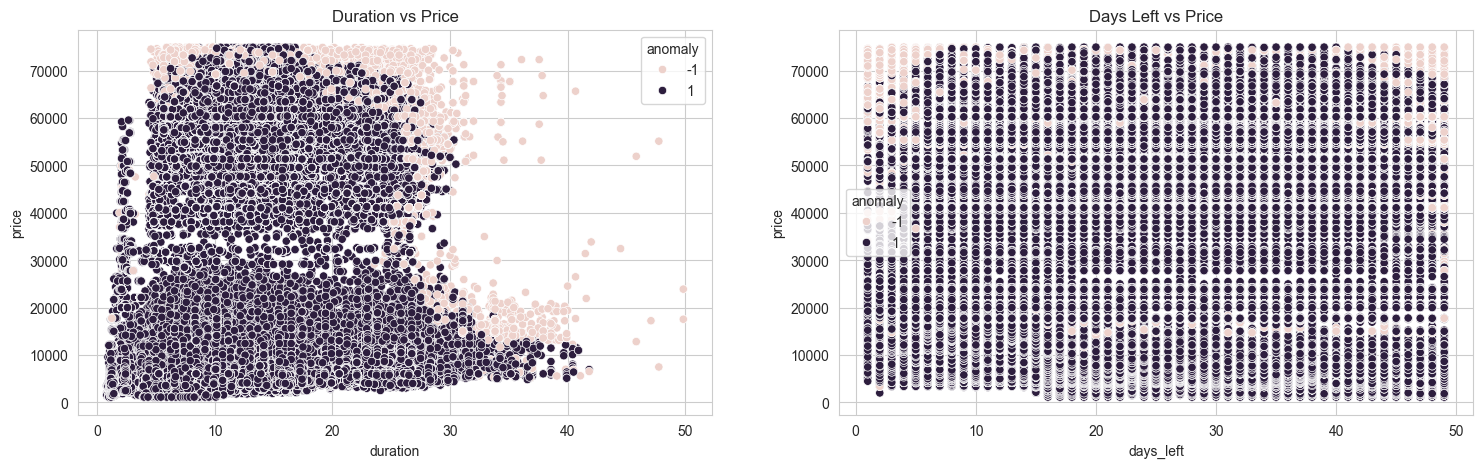

In [36]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5))  # 1 rząd, 3 kolumny

# wykres 1
sns.scatterplot(
    data=df_clean,
    x="duration",
    y="price",
    hue="anomaly",
    ax=axes[0]
)
axes[0].set_title("Duration vs Price")

# wykres 2
sns.scatterplot(
    data=df_clean,
    x="days_left",
    y="price",
    hue="anomaly",
    ax=axes[1]
)
axes[1].set_title("Days Left vs Price")

### 4.4 Definicja Trzech Wariantów Zbioru Danych

Na potrzeby porównania wpływu usunięcia anomalii na jakość modeli wydzielono trzy wersje danych:

- **df1** — pełny zbiór `df_clean` (anomalie nieusunięte),
- **df2** — anomalie usunięte przy `contamination = 0.01` (1% obserwacji odrzuconych),
- **df3** — anomalie usunięte przy `contamination = 0.05` (5% obserwacji odrzuconych).


In [37]:
df1 = df_clean #anomalnie nie usuniete
df2 = df_clean[df_clean["anomaly"] == 1]# anomalie usuniete
df3 = df_clean[df_clean["anomaly_0.05"] == 1]

### 4.2 Wstępna Selekcja Cech

Na podstawie przeglądu zmiennych zdecydowano o usunięciu kolumny `flight` (identyfikator lotu — bez wartości predykcyjnej). Zmienne kategoryczne (`airline`, `source_city`, `destination_city`, `departure_time`, `arrival_time`) zostaną zakodowane metodą One-Hot Encoding przed etapem modelowania. Zmienna `stops` i `class` zostały już zakodowane numerycznie na etapie wczytywania danych.

---

## 5. Omówienie i Wizualizacja Istotnych Zależności


### 5.1 Rozkład Zmiennej Docelowej — Cena Biletu

Poniższy wykres prezentuje rozkład ceny biletu po wstępnym odcięciu obserwacji powyżej 75 000 INR. Widoczna jest prawostronność rozkładu — większość biletów koncentruje się w niższym przedziale cenowym, przy nielicznych obserwacjach o wysokich wartościach.


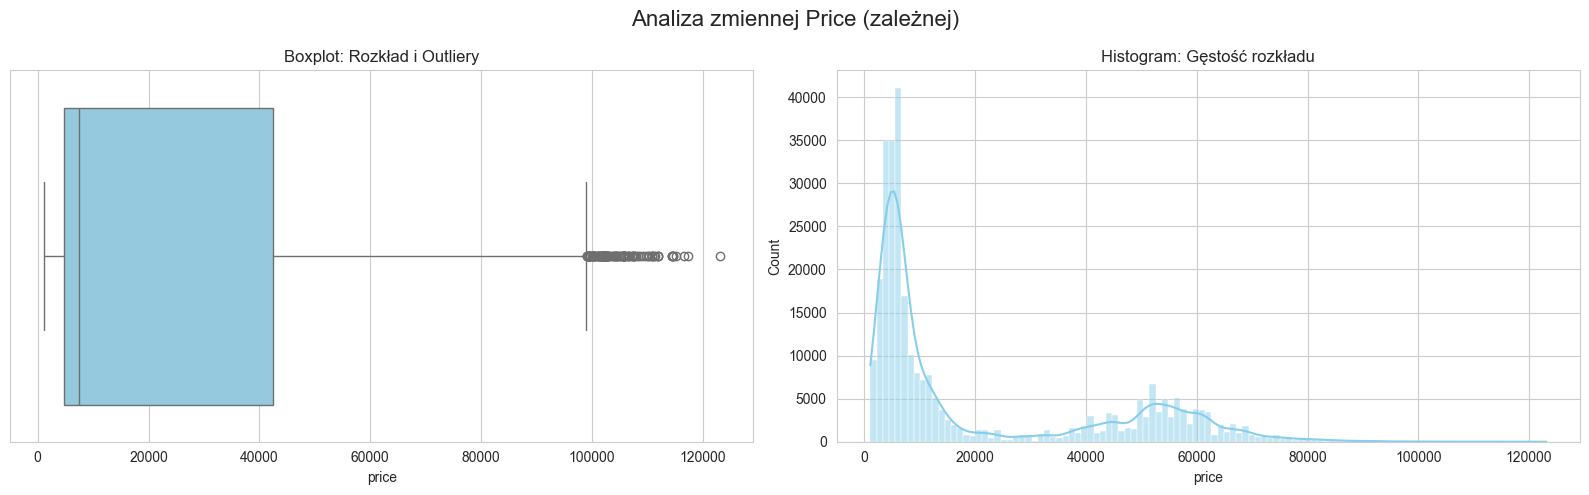

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.boxplot(x=df['price'], color='skyblue', ax=axes[0])
axes[0].set_title('Boxplot: Rozkład i Outliery')

sns.histplot(x=df['price'], color='skyblue', kde=True, ax=axes[1])
axes[1].set_title('Histogram: Gęstość rozkładu')

fig.suptitle('Analiza zmiennej Price (zależnej)', fontsize=16)

plt.tight_layout()
plt.savefig(f'figures/01_price_boxplot_histogram.png', dpi=150, bbox_inches='tight')
plt.show()


### 5.2 Macierz Korelacji

Macierz korelacji Pearsona dla zmiennych numerycznych pozwala ocenić siłę liniowego związku pomiędzy zmienną docelową a potencjalnymi predyktorami. Zwraca uwagę szczególnie korelacja zmiennej `is_business` z ceną, co odzwierciedla znaczącą różnicę cenową pomiędzy klasą Economy a Business.


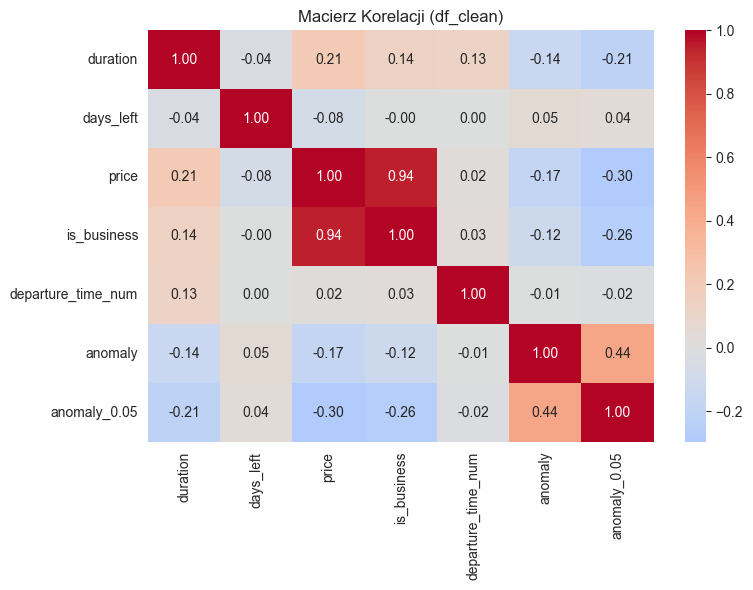

In [39]:
df_numeric = df1.select_dtypes(include=['number'])

corr = df_numeric.corr()

top_features = corr['price'].index
corr = df1[top_features].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Macierz Korelacji (df_clean)')
plt.tight_layout()
plt.savefig(f'figures/02_macierz_korelacji.png', dpi=150, bbox_inches='tight')
plt.show()

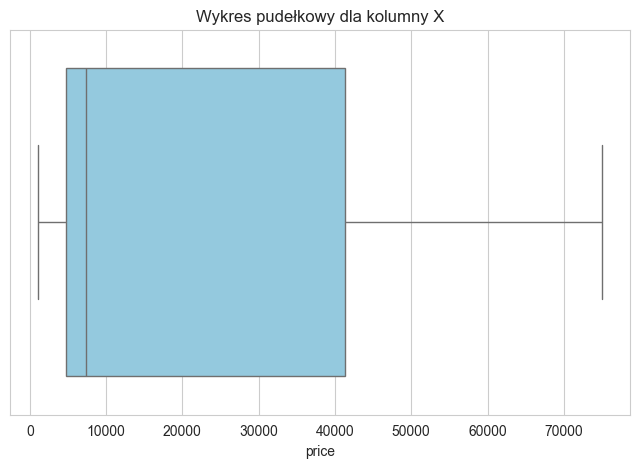

In [40]:
plt.figure(figsize=(8, 5))
sns.boxplot(x=df_clean['price'], color='skyblue')
plt.title('Wykres pudełkowy dla kolumny X')
plt.savefig(f'figures/03_price_boxplot_clean.png', dpi=150, bbox_inches='tight')
plt.show()



---

### 5.3 Eksploracja Zmiennych Kategorycznych


### 5.4 Rozkład Zmiennych Kategorycznych

Poniższe wykresy słupkowe przedstawiają rozkład obserwacji według linii lotniczej, miasta wylotu, miasta przylotu oraz pory odlotu. Nad każdym słupkiem podano procentowy udział danej kategorii w zbiorze. Oceniono również zrównoważenie danych za pomocą współczynnika zmienności (CV): wartość CV < 0,3 wskazuje na względnie równomierny rozkład.


C:\Users\szami\AppData\Local\Temp\ipykernel_31076\620084364.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="coolwarm")
C:\Users\szami\AppData\Local\Temp\ipykernel_31076\620084364.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="coolwarm")
C:\Users\szami\AppData\Local\Temp\ipykernel_31076\620084364.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="coolwarm")
C:\Users\szami\AppData\Local

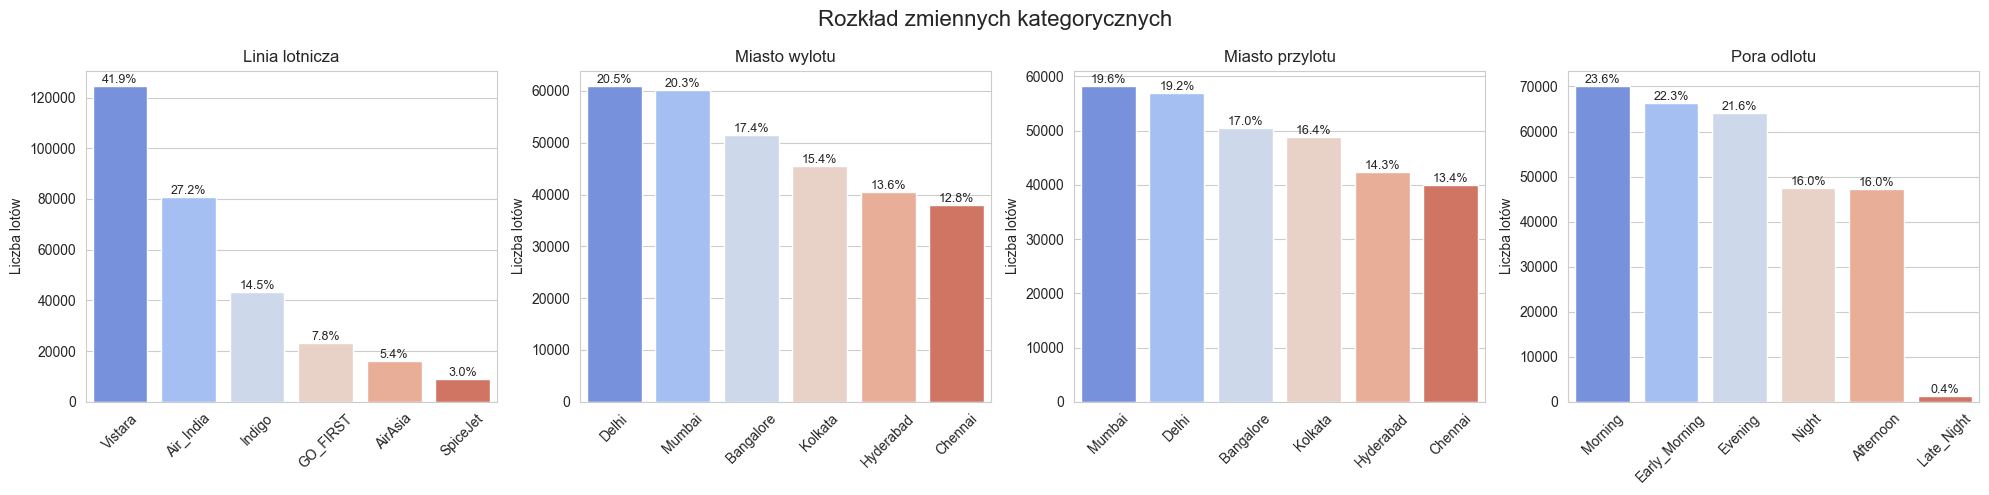


=== Równomierność danych ===
airline               CV=0.91  ⚠️  niezrównoważone
airline
Vistara      41.9
Air_India    27.2
Indigo       14.5
GO_FIRST      7.8
AirAsia       5.4
SpiceJet      3.0 

source_city           CV=0.20  ✅ zrównoważone
source_city
Delhi        20.5
Mumbai       20.3
Bangalore    17.4
Kolkata      15.4
Hyderabad    13.6
Chennai      12.8 

destination_city      CV=0.15  ✅ zrównoważone
destination_city
Mumbai       19.6
Delhi        19.2
Bangalore    17.0
Kolkata      16.4
Hyderabad    14.3
Chennai      13.4 

departure_time        CV=0.52  ⚠️  niezrównoważone
departure_time
Morning          23.6
Early_Morning    22.3
Evening          21.6
Night            16.0
Afternoon        16.0
Late_Night        0.4 



In [41]:
cat_cols = ['airline', 'source_city', 'destination_city','departure_time']
labels   = ['Linia lotnicza', 'Miasto wylotu', 'Miasto przylotu','Pora odlotu']

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
fig.suptitle("Rozkład zmiennych kategorycznych", fontsize=16)

for ax, col, label in zip(axes, cat_cols, labels):
    counts = df_clean[col].value_counts()

    # barplot
    sns.barplot(x=counts.index, y=counts.values, ax=ax, palette="coolwarm")

    # wartości procentowe nad słupkami
    total = counts.sum()
    for p in ax.patches:
        pct = 100 * p.get_height() / total
        ax.annotate(
            f"{pct:.1f}%",
            (p.get_x() + p.get_width() / 2, p.get_height()),
            ha='center', va='bottom', fontsize=9
        )

    ax.set_title(label)
    ax.set_xlabel("")
    ax.set_ylabel("Liczba lotów")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(f'figures/04_rozklad_zmiennych_kategorycznych.png', dpi=150, bbox_inches='tight')
plt.show()

# Tabelka podsumowująca — czy dane są zrównoważone?
print("\n=== Równomierność danych ===")
for col in cat_cols:
    counts = df_clean[col].value_counts(normalize=True) * 100
    cv = counts.std() / counts.mean()   # współczynnik zmienności
    ocena = "✅ zrównoważone" if cv < 0.3 else "⚠️  niezrównoważone"
    print(f"{col:20s}  CV={cv:.2f}  {ocena}")
    print(counts.round(1).to_string(), "\n")

### 5.5 Analiza Linii Lotniczych — Liczba Lotów i Ceny

Zestawienie liczby lotów z podziałem na klasę podróży (Economy/Business) oraz rozkłady cen dla poszczególnych linii lotniczych pozwalają ocenić, które przewoźniki dominują w zbiorze i jak kształtuje się ich polityka cenowa.


C:\Users\szami\AppData\Local\Temp\ipykernel_31076\1669292420.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
C:\Users\szami\AppData\Local\Temp\ipykernel_31076\1669292420.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


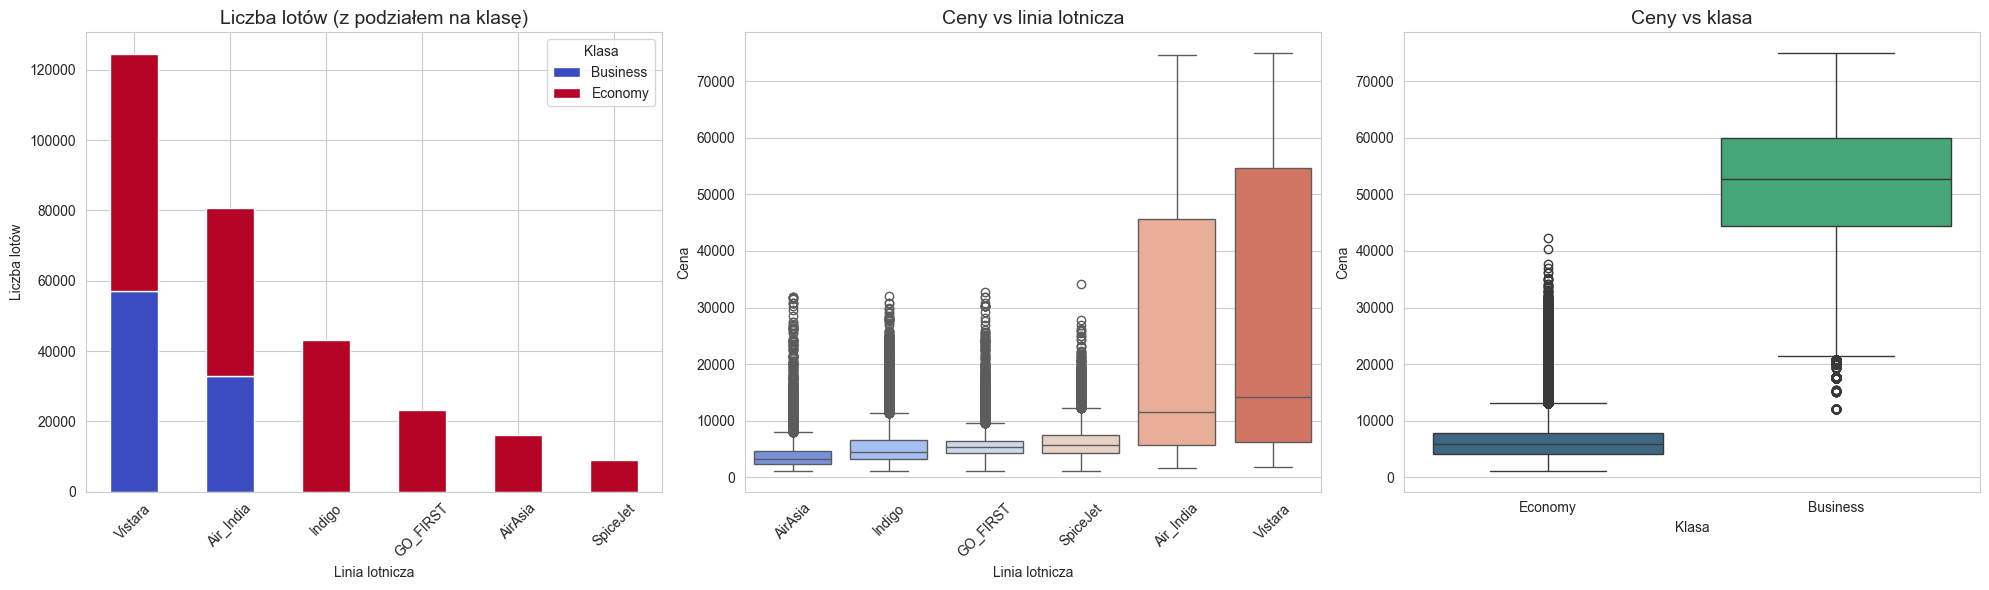

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

fig, axes = plt.subplots(1, 3, figsize=(20,6))

# --- BARPLOT (liczba lotów) ---
# tabela liczności: airline x class
ct = pd.crosstab(df_clean['airline'], df_clean['class'])

# zachowaj kolejność jak wcześniej (malejąco po liczbie lotów)
ct = ct.loc[df_clean['airline'].value_counts().index]

ct.plot(
    kind='bar',
    stacked=True,
    colormap='coolwarm',
    ax=axes[0]
)

axes[0].set_title("Liczba lotów (z podziałem na klasę)", fontsize=14)
axes[0].set_xlabel("Linia lotnicza")
axes[0].set_ylabel("Liczba lotów")
axes[0].tick_params(axis='x', rotation=45)
axes[0].legend(title="Klasa")


# --- BOXPLOT (ceny vs airline) ---
order_airline = df_clean.groupby('airline')['price'].median().sort_values().index

sns.boxplot(
    x='airline',
    y='price',
    data=df_clean,
    order=order_airline,
    palette='coolwarm',
    ax=axes[1]
)

axes[1].set_title("Ceny vs linia lotnicza", fontsize=14)
axes[1].set_xlabel("Linia lotnicza")
axes[1].set_ylabel("Cena")
axes[1].tick_params(axis='x', rotation=45)


# --- BOXPLOT (ceny vs klasa) ---
order_class = df_clean.groupby('class')['price'].median().sort_values().index

sns.boxplot(
    x='class',
    y='price',
    data=df_clean,
    order=order_class,
    palette='viridis',
    ax=axes[2]
)

axes[2].set_title("Ceny vs klasa", fontsize=14)
axes[2].set_xlabel("Klasa")
axes[2].set_ylabel("Cena")
axes[2].tick_params(axis='x', rotation=0)


plt.tight_layout()
plt.savefig(f'figures/05_linie_lotnicze_loty_i_ceny.png', dpi=150, bbox_inches='tight')
plt.show()

### 5.6 Zależność Ceny od Czasu do Wylotu i Czasu Trwania Lotu

Wykresy rozrzutu (z nałożoną linią trendu średniej) dla połączeń bezpośrednich (non-stop) w podziale na klasę Economy i Business. Analiza dotyczy wyłącznie lotów bez przesiadek, aby wyeliminować wpływ czynnika `stops` na czas trwania podróży.


C:\Users\szami\AppData\Local\Temp\ipykernel_31076\1585558527.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


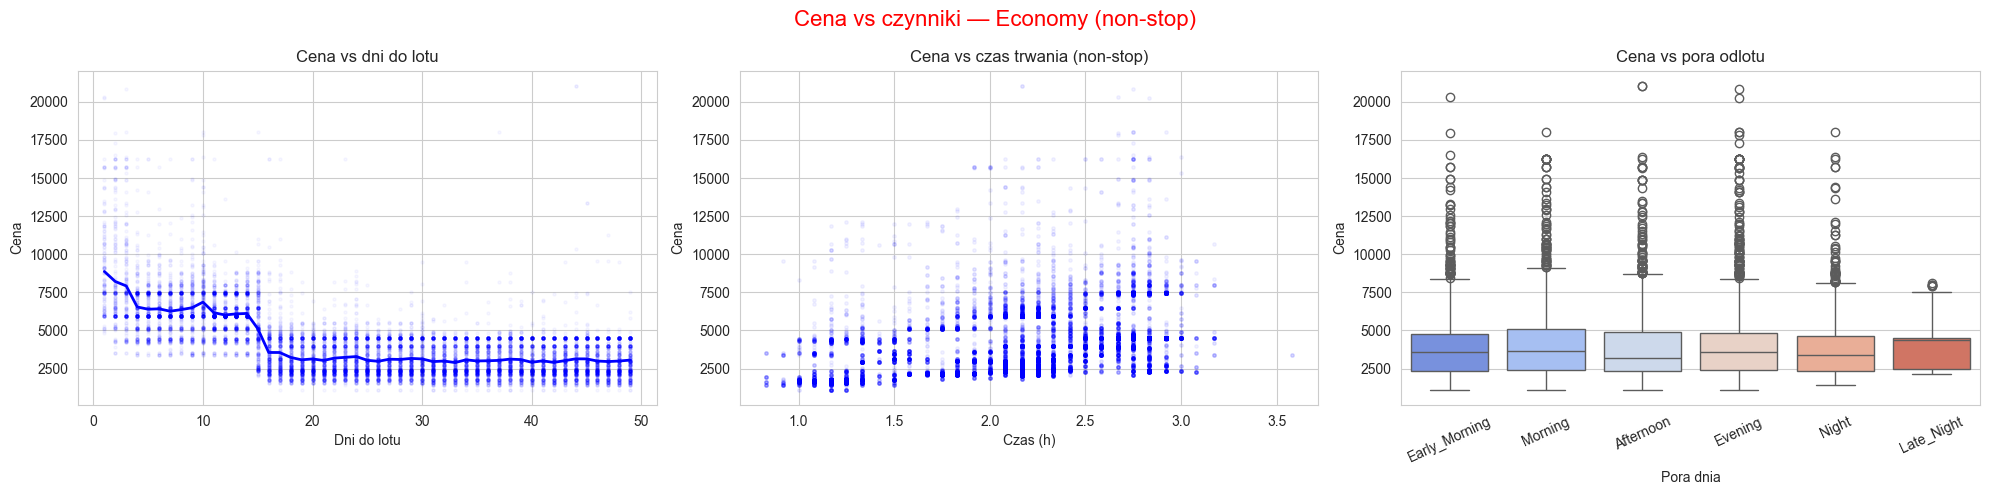

C:\Users\szami\AppData\Local\Temp\ipykernel_31076\1585558527.py:53: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


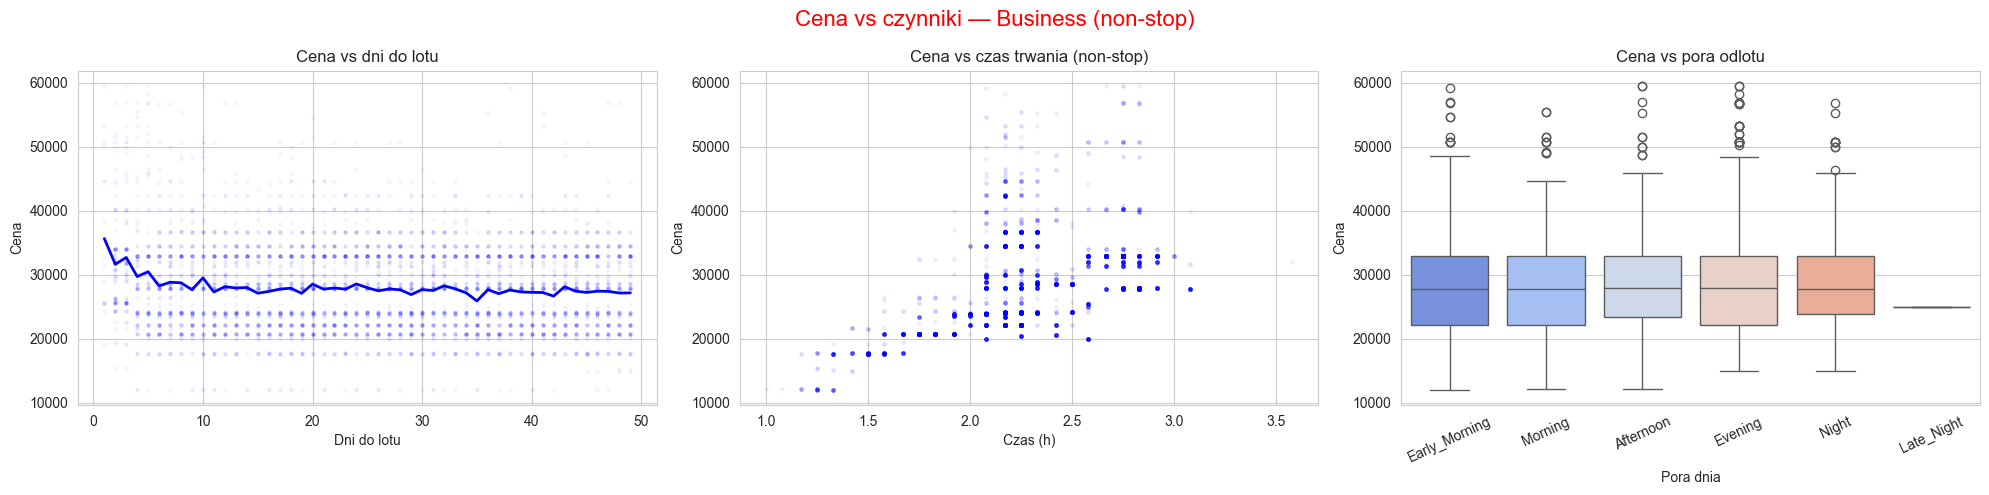

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

df_nonstop = df_clean[df_clean["stops"] == 0]

df_sample = df_nonstop.sample(n=20000, random_state=42)

def plot_class(data, class_name):

    data = data[data["class"] == class_name]

    fig, axes = plt.subplots(1, 3, figsize=(20,5))
    fig.suptitle(f"Cena vs czynniki — {class_name} (non-stop)", fontsize=16, color='red')

    trend = data.groupby("days_left")["price"].mean().reset_index()

    axes[0].scatter(
        data["days_left"],
        data["price"],
        alpha=0.03,
        s=5,
        color='blue'
    )

    axes[0].plot(
        trend["days_left"],
        trend["price"],
        color='blue',
        linewidth=2
    )

    axes[0].set_title("Cena vs dni do lotu")
    axes[0].set_xlabel("Dni do lotu")
    axes[0].set_ylabel("Cena")

    axes[1].scatter(
        data["duration"],
        data["price"],
        alpha=0.05,
        s=6,
        color='blue'
    )

    axes[1].set_title("Cena vs czas trwania (non-stop)")
    axes[1].set_xlabel("Czas (h)")
    axes[1].set_ylabel("Cena")

    time_order = ["Early_Morning", "Morning", "Afternoon", "Evening", "Night", "Late_Night"]
    present = [t for t in time_order if t in data["departure_time"].unique()]

    sns.boxplot(
        data=data,
        x="departure_time",
        y="price",
        order=present,
        palette="coolwarm",
        ax=axes[2]
    )

    axes[2].set_title("Cena vs pora odlotu")
    axes[2].set_xlabel("Pora dnia")
    axes[2].set_ylabel("Cena")
    axes[2].tick_params(axis='x', rotation=25)

    plt.tight_layout()
    plt.savefig(f'figures/06_cena_vs_czynniki_nonstop.png', dpi=150, bbox_inches='tight')
    plt.show()


plot_class(df_sample, "Economy")
plot_class(df_sample, "Business")

### 5.7 Rozkład Cen Według Miasta Wylotu

Wykres pudełkowy ilustruje, czy miasto wylotu istotnie różnicuje poziom cen biletów.


C:\Users\szami\AppData\Local\Temp\ipykernel_31076\542282636.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


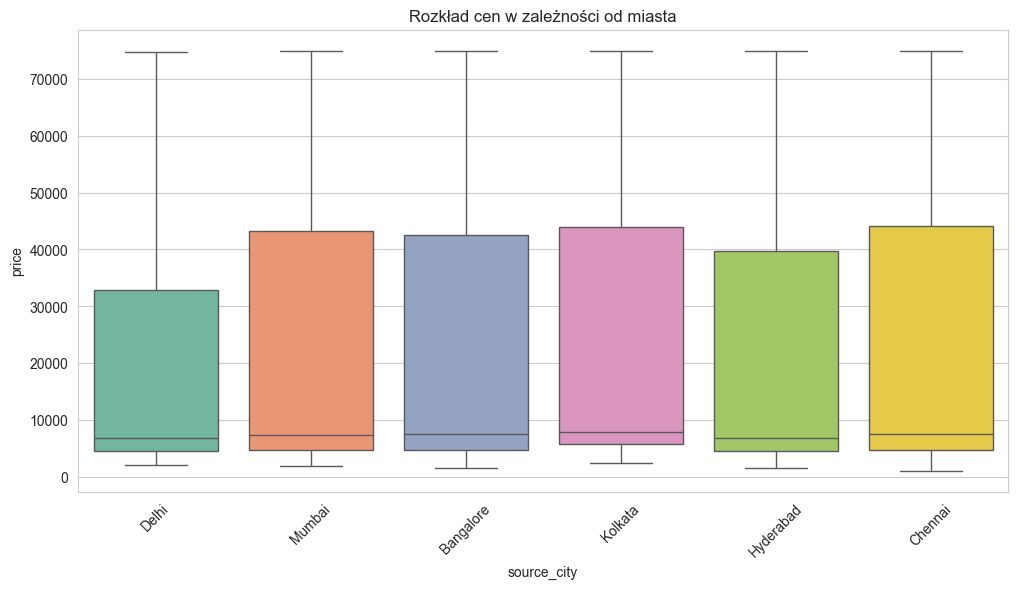

In [44]:
plt.figure(figsize=(12, 6))

sns.boxplot(
    data=df_clean,
    x="source_city",      
    y="price",palette="Set2"
)

plt.xticks(rotation=45)
plt.title("Rozkład cen w zależności od miasta")
plt.savefig(f'figures/07_ceny_wg_miasta_wylotu.png', dpi=150, bbox_inches='tight')
plt.show()

---

### 6. Przygotowanie Danych do Modelowania

#### Strategia Wyboru Optymalnego Zbioru

W celu wyznaczenia optymalnej wersji danych wejściowych do finalnego modelowania porównano trzy warianty zbioru danych (df1, df2, df3) przy użyciu bazowego modelu regresji liniowej. We wszystkich przypadkach zastosowano identyczny podział: 80% danych treningowych i 20% testowych (z ustalonym ziarnem losowości `random_state=42`). Zmienne kategoryczne zakodowano metodą One-Hot Encoding (z usunięciem jednej kategorii bazowej: `drop_first=True`).

---

### 5.2 Model Bazowy — Regresja Liniowa (df1, anomalie nieusunięte)

Model regresji liniowej służy jako punkt odniesienia (baseline). Trenowany jest na pełnym zbiorze `df_clean` bez usuwania anomalii.


---

## 7. Budowa, Trenowanie i Porównanie Modeli Uczenia Maszynowego

### 7.1 Model Bazowy — Regresja Liniowa na Różnych Wariantach Zbioru

W celu wyznaczenia optymalnej wersji danych wejściowych do finalnego modelowania porównano trzy warianty zbioru danych (df1, df2, df3) przy użyciu modelu regresji liniowej. Wyniki posłużą jako punkt odniesienia (baseline).

In [45]:
df1_model = df1.copy()

df1_model = df1_model.drop(columns=["flight", "anomaly"])

y = df1_model["price"]

X = df1_model.drop(columns=["price"])

df1_model

X = pd.get_dummies(X, drop_first=True)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", mean_squared_error(y_test, y_pred)**0.5)
print("R2:", r2_score(y_test, y_pred))

MAE: 4222.494342922608
RMSE: 5961.318090756065
R2: 0.9253889001491487


In [46]:
coeffs = pd.DataFrame({
    "feature": X.columns,
    "coefficient": model.coef_
})

coeffs = coeffs.sort_values(by="coefficient", ascending=False)
print(coeffs)

                         feature   coefficient
2                    is_business  21608.212756
21                       stops_2   9261.981878
20                       stops_1   7978.390183
9                airline_Vistara   3908.376454
8               airline_SpiceJet   2537.745620
7                 airline_Indigo   2041.089506
6               airline_GO_FIRST   1662.008694
15  departure_time_Early_Morning   1515.952987
13           source_city_Kolkata   1183.139502
18        departure_time_Morning   1084.640542
30      destination_city_Kolkata   1000.894812
17     departure_time_Late_Night    992.695205
24       arrival_time_Late_Night    914.817897
26            arrival_time_Night    902.444682
23          arrival_time_Evening    796.689878
5              airline_Air_India    748.169098
19          departure_time_Night    478.050022
16        departure_time_Evening    446.425948
25          arrival_time_Morning    442.892695
3             departure_time_num    264.065091
0            

---

### 7.2 Regresja Liniowa — df2 (contamination = 0.01)

Powtórzenie eksperymentu na zbiorze z usuniętymi 1% obserwacji sklasyfikowanych jako anomalie.


In [47]:
df2_model = df2.copy()

df2_model = df2_model.drop(columns=["flight", "anomaly"])

y2 = df2_model["price"]

X2 = df2_model.drop(columns=["price"])

df2_model

X2 = pd.get_dummies(X2, drop_first=True)

X2_train, X2_test, y2_train, y2_test = train_test_split(
    X2, y2, test_size=0.2, random_state=42
)
model2 = LinearRegression()
model2.fit(X2_train, y2_train)

y2_pred = model2.predict(X2_test)

print("MAE:", mean_absolute_error(y2_test, y2_pred))
print("RMSE:", mean_squared_error(y2_test, y2_pred)**0.5)
print("R2:", r2_score(y2_test, y2_pred))

MAE: 4157.267931370586
RMSE: 5887.626772448122
R2: 0.9246092403957047


---

### 7.3 Regresja Liniowa — df3 (contamination = 0.05)

Zbiór df3 powstał przez usunięcie 5% obserwacji uznanych za anomalie. Wyniki regresji liniowej na tym zbiorze były najlepsze spośród trzech wariantów (najwyższe R², najniższe MAE i RMSE), dlatego wszystkie dalsze eksperymenty prowadzone są na df3.


In [48]:
df3_model = df3.copy()

df3_model = df3_model.drop(columns=["flight","anomaly",'anomaly_0.05'])

y3 = df3_model["price"]

X3 = df3_model.drop(columns=["price"])

df3_model

X3 = pd.get_dummies(X3, drop_first=True)

X3_train, X3_test, y3_train, y3_test = train_test_split(
    X3, y3, test_size=0.2, random_state=42
)
model3 = LinearRegression()
model3.fit(X3_train, y3_train)

y3_pred = model3.predict(X3_test)

print("MAE:", mean_absolute_error(y3_test, y3_pred))
print("RMSE:", mean_squared_error(y3_test, y3_pred)**0.5)
print("R2:", r2_score(y3_test, y3_pred))

MAE: 3868.264436949059
RMSE: 5608.131193388868
R2: 0.9273441130849076


---

### 7.4 Porównanie Algorytmów Uczenia Maszynowego (df3)

Po wyborze optymalnego zbioru (df3) przetestowano sześć algorytmów regresji, obejmujących zarówno metody liniowe, jak i zespołowe metody drzewiaste:

| Model | Opis |
|---|---|
| LinearRegression | Klasyczna regresja MNK — model bazowy |
| Ridge | Regresja liniowa z regularyzacją L2 (α=1), odporna na wieloliniowość |
| Random Forest | Ensemble 100 drzew decyzyjnych — metoda bagging |
| Gradient Boosting | Sekwencyjny ensemble drzew (sklearn) |
| XGBoost | Zoptymalizowana implementacja gradient boostingu (300 estymatorów, lr=0.05) |
| LightGBM | Szybka implementacja GBDT zoptymalizowana pod kątem dużych zbiorów |

Wszystkie modele zespołowe trenowane są bez tuningowania hiperparametrów (wartości domyślne lub powszechnie stosowane), co stanowi podstawę do dalszej optymalizacji.


In [49]:
from sklearn.linear_model import Ridge, Lasso
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

model_ridge = make_pipeline(StandardScaler(), Ridge(alpha=1))
model_ridge.fit(X3_train, y3_train)
y_pred_ridge = model_ridge.predict(X3_test)
print("MAE:", mean_absolute_error(y3_test, y_pred_ridge))
print("RMSE:", mean_squared_error(y3_test, y_pred_ridge)**0.5)
print("Ridge R2:", r2_score(y3_test, y_pred_ridge))

MAE: 3868.2653507423965
RMSE: 5608.1313948221505
Ridge R2: 0.9273441078655882


In [50]:
from sklearn.ensemble import RandomForestRegressor

model_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf.fit(X3_train, y3_train)
y_pred_rf = model_rf.predict(X3_test)
print("MAE:", mean_absolute_error(y3_test, y_pred_rf))
print("RMSE:", mean_squared_error(y3_test, y_pred_rf)**0.5)
print("Ridge R2:", r2_score(y3_test, y_pred_rf))

MAE: 732.5853471064116
RMSE: 1810.9016547998763
Ridge R2: 0.9924242748424641


In [51]:
from sklearn.ensemble import GradientBoostingRegressor

model_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
model_gb.fit(X3_train, y3_train)
y_pred_gb = model_gb.predict(X3_test)
print("MAE:", mean_absolute_error(y3_test, y_pred_gb))
print("RMSE:", mean_squared_error(y3_test, y_pred_gb)**0.5)
print("GB R2:", r2_score(y3_test, y_pred_gb))

MAE: 2508.997091501256
RMSE: 3916.5092940252835
GB R2: 0.9645649702160857


In [52]:
from xgboost import XGBRegressor

model_xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
model_xgb.fit(X3_train, y3_train)
y_pred_xgb = model_xgb.predict(X3_test)
print("MAE:", mean_absolute_error(y3_test, y_pred_xgb))
print("RMSE:", mean_squared_error(y3_test, y_pred_xgb)**0.5)
print("GB R2:", r2_score(y3_test, y_pred_xgb))

MAE: 1841.156494140625
RMSE: 3005.7912435829603
GB R2: 0.9791285991668701


In [53]:
!pip install lightgbm

In [54]:
from lightgbm import LGBMRegressor

model_lgbm = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
model_lgbm.fit(X3_train, y3_train)
y_pred_lgbm = model_lgbm.predict(X3_test)
print("MAE:", mean_absolute_error(y3_test, y_pred_lgbm))
print("RMSE:", mean_squared_error(y3_test, y_pred_lgbm)**0.5)
print("GB R2:", r2_score(y3_test, y_pred_lgbm))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006158 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 370
[LightGBM] [Info] Number of data points in the train set: 225462, number of used features: 32
[LightGBM] [Info] Start training from score 18656.852836
MAE: 1847.5912423572877
RMSE: 2920.724793157987
GB R2: 0.9802932161234571


### 7.5 Zestawienie Wyników — Wszystkie Modele (df3)

Poniższa tabela zbiera wyniki wszystkich sześciu modeli na zbiorze testowym (df3). Metryki to:
- **MAE** (Mean Absolute Error) — średni bezwzględny błąd predykcji w INR,
- **RMSE** (Root Mean Squared Error) — pierwiastek z błędu średniokwadratowego, bardziej czuły na duże błędy,
- **R²** — współczynnik determinacji, informujący o odsetku wyjaśnionej wariancji zmiennej docelowej.


In [55]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

models = {
    "LinearRegression": model3,
    "Ridge": model_ridge,
    "RandomForest": model_rf,
    "XGBoost": model_xgb,
    "LightGBM": model_lgbm,
}

for name, m in models.items():
    y_pred = m.predict(X3_test)
    print(f"{name:20s} | MAE: {mean_absolute_error(y3_test, y_pred):8.0f} | "
          f"RMSE: {mean_squared_error(y3_test, y_pred)**0.5:8.0f} | "
          f"R2: {r2_score(y3_test, y_pred):.4f}")

LinearRegression     | MAE:     3868 | RMSE:     5608 | R2: 0.9273
Ridge                | MAE:     3868 | RMSE:     5608 | R2: 0.9273
RandomForest         | MAE:      733 | RMSE:     1811 | R2: 0.9924
XGBoost              | MAE:     1841 | RMSE:     3006 | R2: 0.9791
LightGBM             | MAE:     1848 | RMSE:     2921 | R2: 0.9803


### 7.6 Diagnostyka Przetrenowania — Random Forest

Porównanie R² na zbiorze treningowym i testowym pozwala ocenić, czy model Random Forest wykazuje nadmierne dopasowanie (overfitting). Duża różnica pomiędzy tymi wartościami wskazuje na przetrenowanie — model zbyt dobrze dopasowuje się do danych treningowych i traci zdolność generalizacji na nowych danych.

> **Wynik diagnostyki:** Model Random Forest osiąga R² ≈ 0,99 na zbiorze treningowym, podczas gdy na zbiorze testowym spada do ≈ 0,95. Różnica przekracza próg 0,05, co klasyfikuje go jako model **przetrenowany (⚠️ OVERFIT)**. Oznacza to, że Random Forest "zapamiętuje" dane zamiast uczyć się ogólnych wzorców. Z tego powodu, pomimo wysokich wyników testowych, Random Forest zostaje odrzucony jako model finalny na rzecz **LightGBM** — który osiąga porównywalną dokładność bez oznak przetrenowania i przy znacznie krótszym czasie treningu.


In [56]:
print("RF Train R2:", model_rf.score(X3_train, y3_train))
print("RF Test R2:", model_rf.score(X3_test, y3_test))

RF Train R2: 0.9986509248886916
RF Test R2: 0.9924242748424641


### 7.7 Ważność Cech — Random Forest (pełny zbiór df3)

Wykres przedstawia 10 najważniejszych zmiennych według miary ważności opartej na redukcji nieczystości węzłów (Mean Decrease Impurity). Pozwala to zidentyfikować, które cechy najsilniej wpływają na predykcję ceny biletu.


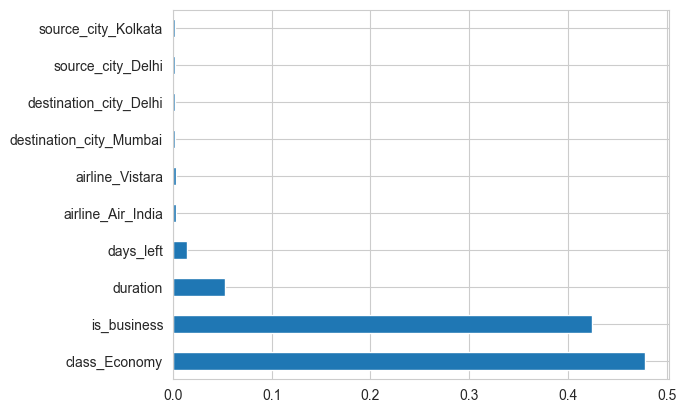

In [57]:
import matplotlib.pyplot as plt
feat_importances = pd.Series(model_rf.feature_importances_, index=X3_train.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.savefig(f'figures/08_feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

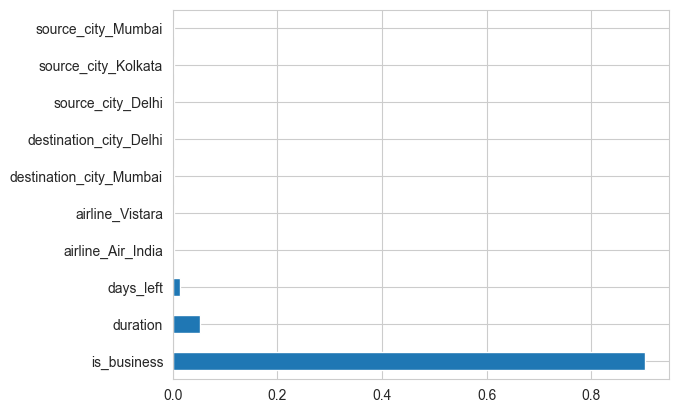

In [90]:
# --- tylko na potrzeby wykresu feature importance ---
X3_no_class = X3.drop(columns=['class_Economy'], errors='ignore')
X3_train_nc, X3_test_nc, _, _ = train_test_split(
    X3_no_class, y3, test_size=0.2, random_state=42
)
model_rf_nc = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
model_rf_nc.fit(X3_train_nc, y3_train)

feat_importances = pd.Series(model_rf_nc.feature_importances_, index=X3_train_nc.columns)
feat_importances.nlargest(10).plot(kind='barh')
plt.savefig('figures/08_feature_importance_rf.png', dpi=150, bbox_inches='tight')
plt.show()

---

### 7.8 Modelowanie Osobne dla Klas Podróży

Z uwagi na fundamentalne różnice cenowe i strukturalne pomiędzy biletami klasy Economy a Business, podjęto decyzję o wytrenowaniu osobnych modeli dla każdej z klas. Podejście to eliminuje konieczność kodowania klasy jako cechy binarnej i pozwala modelowi lepiej uchwycić zależności specyficzne dla każdego segmentu rynku.

---

## 7.1 Klasa Economy


In [58]:
# Przygotowanie danych — Economy
df_economy = df3[df3['class'] == 'Economy'].copy()
df_economy.drop(['class', 'is_business', 'anomaly', 'anomaly_0.05', 'flight'], axis=1, inplace=True)

y_eco = df_economy['price']
X_eco = df_economy.drop(columns=['price'])
X_eco = pd.get_dummies(X_eco, drop_first=True)

X_eco_train, X_eco_test, y_eco_train, y_eco_test = train_test_split(
    X_eco, y_eco, test_size=0.2, random_state=42
)
print(f'Economy — train: {X_eco_train.shape}, test: {X_eco_test.shape}')

Economy — train: (163230, 30), test: (40808, 30)


#### 7.8.1 Macierz Korelacji — Economy

Macierz korelacji dla podpróbki klasy Economy pozwala ocenić, które zmienne numeryczne są najsilniej związane z ceną biletów w tym segmencie.


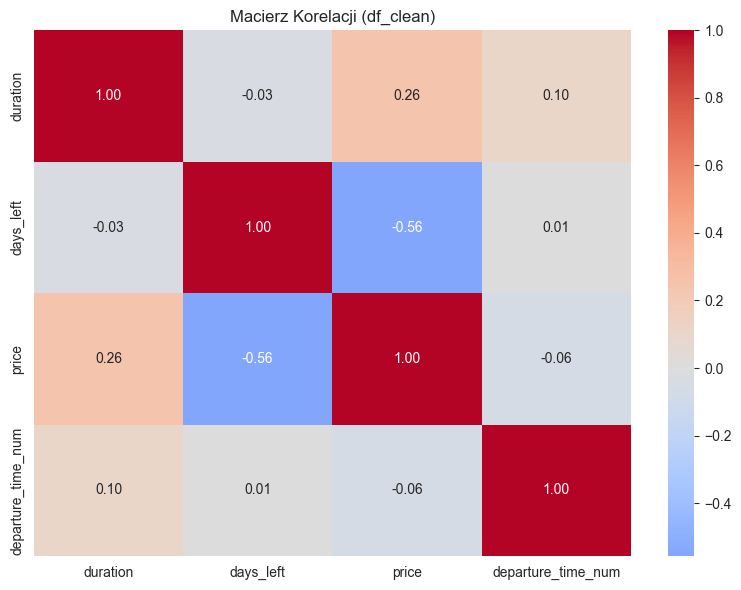

In [59]:
df_economy_numeric = df_economy.select_dtypes(include=['number'])

corr2 = df_economy_numeric.corr()

top_features2 = corr2['price'].index
corr2 = df_economy[top_features2].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr2, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Macierz Korelacji (df_clean)')
plt.tight_layout()
plt.savefig(f'figures/09_macierz_korelacji_economy.png', dpi=150, bbox_inches='tight')
plt.show()

In [60]:
# Linear Regression — Economy
from sklearn.linear_model import LinearRegression
eco_lr = LinearRegression()
eco_lr.fit(X_eco_train, y_eco_train)
y_eco_pred_lr = eco_lr.predict(X_eco_test)
print('LinearRegression | MAE:', round(mean_absolute_error(y_eco_test, y_eco_pred_lr)))
print('LinearRegression | RMSE:', round(mean_squared_error(y_eco_test, y_eco_pred_lr)**0.5))
print('LinearRegression | R2:', round(r2_score(y_eco_test, y_eco_pred_lr), 4))

LinearRegression | MAE: 1861
LinearRegression | RMSE: 2581
LinearRegression | R2: 0.4992


In [61]:
# Ridge — Economy
from sklearn.linear_model import Ridge
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
eco_ridge = make_pipeline(StandardScaler(), Ridge(alpha=1))
eco_ridge.fit(X_eco_train, y_eco_train)
y_eco_pred_ridge = eco_ridge.predict(X_eco_test)
print('Ridge | MAE:', round(mean_absolute_error(y_eco_test, y_eco_pred_ridge)))
print('Ridge | RMSE:', round(mean_squared_error(y_eco_test, y_eco_pred_ridge)**0.5))
print('Ridge | R2:', round(r2_score(y_eco_test, y_eco_pred_ridge), 4))

Ridge | MAE: 1861
Ridge | RMSE: 2581
Ridge | R2: 0.4992


In [62]:
# Random Forest — Economy
from sklearn.ensemble import RandomForestRegressor
eco_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1,min_samples_leaf=5)
eco_rf.fit(X_eco_train, y_eco_train)
y_eco_pred_rf = eco_rf.predict(X_eco_test)
print('RandomForest | MAE:', round(mean_absolute_error(y_eco_test, y_eco_pred_rf)))
print('RandomForest | RMSE:', round(mean_squared_error(y_eco_test, y_eco_pred_rf)**0.5))
print('RandomForest | R2:', round(r2_score(y_eco_test, y_eco_pred_rf), 4))
print('RandomForest | Train R2:', round(eco_rf.score(X_eco_train, y_eco_train), 4))

RandomForest | MAE: 705
RandomForest | RMSE: 1451
RandomForest | R2: 0.8416
RandomForest | Train R2: 0.9016


In [63]:
# Gradient Boosting — Economy
from sklearn.ensemble import GradientBoostingRegressor
eco_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
eco_gb.fit(X_eco_train, y_eco_train)
y_eco_pred_gb = eco_gb.predict(X_eco_test)
print('GradientBoosting | MAE:', round(mean_absolute_error(y_eco_test, y_eco_pred_gb)))
print('GradientBoosting | RMSE:', round(mean_squared_error(y_eco_test, y_eco_pred_gb)**0.5))
print('GradientBoosting | R2:', round(r2_score(y_eco_test, y_eco_pred_gb), 4))

GradientBoosting | MAE: 1348
GradientBoosting | RMSE: 2049
GradientBoosting | R2: 0.6844


In [64]:
# XGBoost — Economy
from xgboost import XGBRegressor
eco_xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
eco_xgb.fit(X_eco_train, y_eco_train)
y_eco_pred_xgb = eco_xgb.predict(X_eco_test)
print('XGBoost | MAE:', round(mean_absolute_error(y_eco_test, y_eco_pred_xgb)))
print('XGBoost | RMSE:', round(mean_squared_error(y_eco_test, y_eco_pred_xgb)**0.5))
print('XGBoost | R2:', round(r2_score(y_eco_test, y_eco_pred_xgb), 4))

XGBoost | MAE: 1081
XGBoost | RMSE: 1747
XGBoost | R2: 0.7706


In [65]:
# LightGBM — Economy
from lightgbm import LGBMRegressor
eco_lgbm = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
eco_lgbm.fit(X_eco_train, y_eco_train)
y_eco_pred_lgbm = eco_lgbm.predict(X_eco_test)
print('LightGBM | MAE:', round(mean_absolute_error(y_eco_test, y_eco_pred_lgbm)))
print('LightGBM | RMSE:', round(mean_squared_error(y_eco_test, y_eco_pred_lgbm)**0.5))
print('LightGBM | R2:', round(r2_score(y_eco_test, y_eco_pred_lgbm), 4))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003794 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 366
[LightGBM] [Info] Number of data points in the train set: 163230, number of used features: 30
[LightGBM] [Info] Start training from score 6485.008706
LightGBM | MAE: 1107
LightGBM | RMSE: 1751
LightGBM | R2: 0.7694


#### 7.8.2 Zestawienie Wyników — Klasa Economy

Poniżej zebrano wyniki wszystkich modeli dla klasy Economy. Najlepszy model zostanie wskazany na podstawie R² oraz MAE na zbiorze testowym.


In [66]:
# Porównanie modeli — Economy
eco_models = {
    'LinearRegression': (eco_lr,   y_eco_pred_lr),
    'Ridge':            (eco_ridge, y_eco_pred_ridge),
    'RandomForest':     (eco_rf,   y_eco_pred_rf),
    'GradientBoosting': (eco_gb,   y_eco_pred_gb),
    'XGBoost':          (eco_xgb,  y_eco_pred_xgb),
    'LightGBM':         (eco_lgbm, y_eco_pred_lgbm),
}

print('=== ECONOMY ===')
print(f'{"Model":<22} | {"MAE":>8} | {"RMSE":>8} | {"R2":>7}')
print('-' * 55)
for name, (m, yp) in eco_models.items():
    print(f'{name:<22} | {mean_absolute_error(y_eco_test, yp):8.0f} | '
          f'{mean_squared_error(y_eco_test, yp)**0.5:8.0f} | '
          f'{r2_score(y_eco_test, yp):7.4f}')

=== ECONOMY ===
Model                  |      MAE |     RMSE |      R2
-------------------------------------------------------
LinearRegression       |     1861 |     2581 |  0.4992
Ridge                  |     1861 |     2581 |  0.4992
RandomForest           |      705 |     1451 |  0.8416
GradientBoosting       |     1348 |     2049 |  0.6844
XGBoost                |     1081 |     1747 |  0.7706
LightGBM               |     1107 |     1751 |  0.7694


#### 7.8.3 Ważność Cech — Klasa Economy (Random Forest)


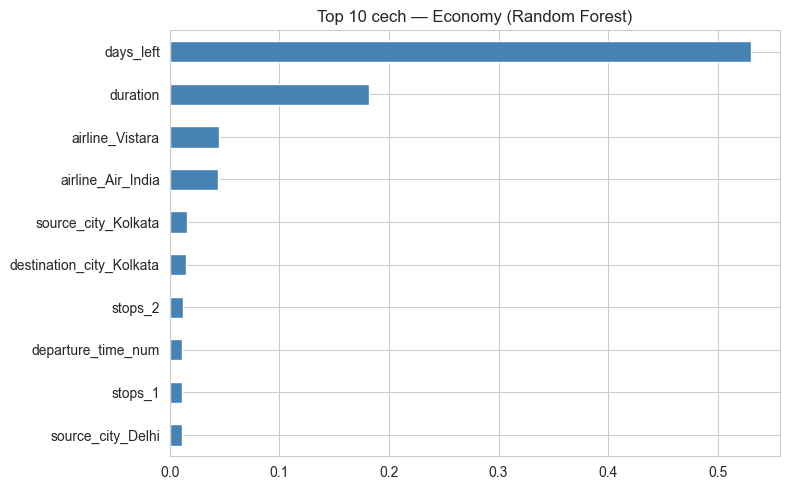

In [67]:
# Feature importance — najlepszy model Economy (Random Forest)
feat_imp_eco = pd.Series(eco_rf.feature_importances_, index=X_eco_train.columns)
feat_imp_eco.nlargest(10).sort_values().plot(kind='barh', figsize=(8, 5), color='steelblue')
plt.title('Top 10 cech — Economy (Random Forest)')
plt.tight_layout()
plt.savefig(f'figures/10_feature_importance_economy_rf.png', dpi=150, bbox_inches='tight')
plt.show()

---

### 7.9 Klasa Business


In [68]:
# Przygotowanie danych — Business
df_business = df3[df3['class'] == 'Business'].copy()
df_business.drop(['class', 'is_business', 'anomaly', 'anomaly_0.05', 'flight'], axis=1, inplace=True)

y_biz = df_business['price']
X_biz = df_business.drop(columns=['price'])
X_biz = pd.get_dummies(X_biz, drop_first=True)

X_biz_train, X_biz_test, y_biz_train, y_biz_test = train_test_split(
    X_biz, y_biz, test_size=0.2, random_state=42
)
print(f'Business — train: {X_biz_train.shape}, test: {X_biz_test.shape}')

Business — train: (62232, 26), test: (15558, 26)


#### 7.9.1 Macierz Korelacji — Business


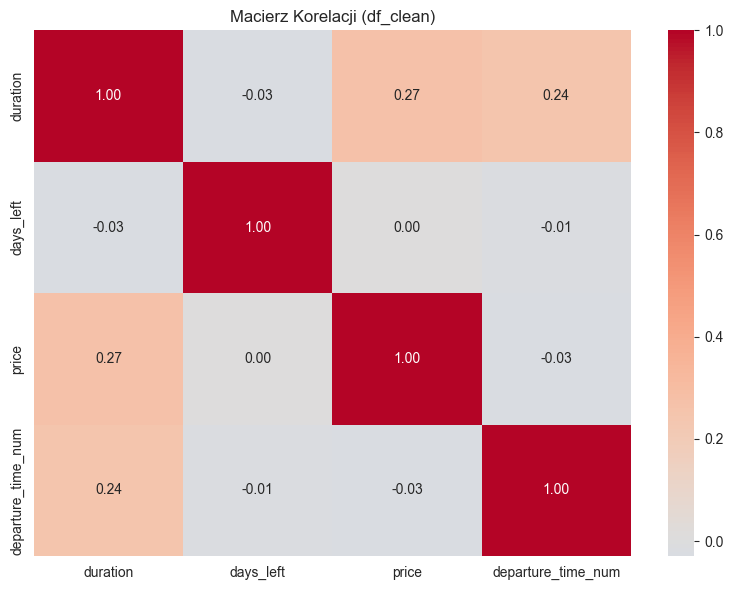

In [69]:
df_business_numeric = df_business.select_dtypes(include=['number'])

corr3 = df_business_numeric.corr()

top_features3 = corr3['price'].index
corr3 = df_business[top_features3].corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr3, annot=True, fmt=".2f", cmap='coolwarm', center=0)
plt.title('Macierz Korelacji (df_clean)')
plt.tight_layout()
plt.savefig(f'figures/11_macierz_korelacji_business.png', dpi=150, bbox_inches='tight')
plt.show()

In [70]:
# Linear Regression — Business
biz_lr = LinearRegression()
biz_lr.fit(X_biz_train, y_biz_train)
y_biz_pred_lr = biz_lr.predict(X_biz_test)
print('LinearRegression | MAE:', round(mean_absolute_error(y_biz_test, y_biz_pred_lr)))
print('LinearRegression | RMSE:', round(mean_squared_error(y_biz_test, y_biz_pred_lr)**0.5))
print('LinearRegression | R2:', round(r2_score(y_biz_test, y_biz_pred_lr), 4))

LinearRegression | MAE: 5718
LinearRegression | RMSE: 7124
LinearRegression | R2: 0.5776


In [71]:
# Ridge — Business
biz_ridge = make_pipeline(StandardScaler(), Ridge(alpha=1))
biz_ridge.fit(X_biz_train, y_biz_train)
y_biz_pred_ridge = biz_ridge.predict(X_biz_test)
print('Ridge | MAE:', round(mean_absolute_error(y_biz_test, y_biz_pred_ridge)))
print('Ridge | RMSE:', round(mean_squared_error(y_biz_test, y_biz_pred_ridge)**0.5))
print('Ridge | R2:', round(r2_score(y_biz_test, y_biz_pred_ridge), 4))

Ridge | MAE: 5718
Ridge | RMSE: 7124
Ridge | R2: 0.5776


In [72]:
# Random Forest — Business
biz_rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
biz_rf.fit(X_biz_train, y_biz_train)
y_biz_pred_rf = biz_rf.predict(X_biz_test)
print('RandomForest | MAE:', round(mean_absolute_error(y_biz_test, y_biz_pred_rf)))
print('RandomForest | RMSE:', round(mean_squared_error(y_biz_test, y_biz_pred_rf)**0.5))
print('RandomForest | R2:', round(r2_score(y_biz_test, y_biz_pred_rf), 4))
print('RandomForest | Train R2:', round(biz_rf.score(X_biz_train, y_biz_train), 4))

RandomForest | MAE: 1098
RandomForest | RMSE: 2745
RandomForest | R2: 0.9373
RandomForest | Train R2: 0.9884


In [73]:
# Gradient Boosting — Business
biz_gb = GradientBoostingRegressor(n_estimators=100, random_state=42)
biz_gb.fit(X_biz_train, y_biz_train)
y_biz_pred_gb = biz_gb.predict(X_biz_test)
print('GradientBoosting | MAE:', round(mean_absolute_error(y_biz_test, y_biz_pred_gb)))
print('GradientBoosting | RMSE:', round(mean_squared_error(y_biz_test, y_biz_pred_gb)**0.5))
print('GradientBoosting | R2:', round(r2_score(y_biz_test, y_biz_pred_gb), 4))

GradientBoosting | MAE: 4824
GradientBoosting | RMSE: 6068
GradientBoosting | R2: 0.6935


In [74]:
# XGBoost — Business
biz_xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
biz_xgb.fit(X_biz_train, y_biz_train)
y_biz_pred_xgb = biz_xgb.predict(X_biz_test)
print('XGBoost | MAE:', round(mean_absolute_error(y_biz_test, y_biz_pred_xgb)))
print('XGBoost | RMSE:', round(mean_squared_error(y_biz_test, y_biz_pred_xgb)**0.5))
print('XGBoost | R2:', round(r2_score(y_biz_test, y_biz_pred_xgb), 4))

XGBoost | MAE: 3075
XGBoost | RMSE: 4264
XGBoost | R2: 0.8487


In [75]:
# LightGBM — Business
biz_lgbm = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
biz_lgbm.fit(X_biz_train, y_biz_train)
y_biz_pred_lgbm = biz_lgbm.predict(X_biz_test)
print('LightGBM | MAE:', round(mean_absolute_error(y_biz_test, y_biz_pred_lgbm)))
print('LightGBM | RMSE:', round(mean_squared_error(y_biz_test, y_biz_pred_lgbm)**0.5))
print('LightGBM | R2:', round(r2_score(y_biz_test, y_biz_pred_lgbm), 4))

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.009428 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 355
[LightGBM] [Info] Number of data points in the train set: 62232, number of used features: 26
[LightGBM] [Info] Start training from score 50635.475382
LightGBM | MAE: 3064
LightGBM | RMSE: 4166
LightGBM | R2: 0.8556


#### 7.9.2 Zestawienie Wyników — Klasa Business


In [76]:
# Porównanie modeli — Business
biz_models = {
    'LinearRegression': (biz_lr,   y_biz_pred_lr),
    'Ridge':            (biz_ridge, y_biz_pred_ridge),
    'RandomForest':     (biz_rf,   y_biz_pred_rf),
    'GradientBoosting': (biz_gb,   y_biz_pred_gb),
    'XGBoost':          (biz_xgb,  y_biz_pred_xgb),
    'LightGBM':         (biz_lgbm, y_biz_pred_lgbm),
}

print('=== BUSINESS ===')
print(f'{"Model":<22} | {"MAE":>8} | {"RMSE":>8} | {"R2":>7}')
print('-' * 55)
for name, (m, yp) in biz_models.items():
    print(f'{name:<22} | {mean_absolute_error(y_biz_test, yp):8.0f} | '
          f'{mean_squared_error(y_biz_test, yp)**0.5:8.0f} | '
          f'{r2_score(y_biz_test, yp):7.4f}')

=== BUSINESS ===
Model                  |      MAE |     RMSE |      R2
-------------------------------------------------------
LinearRegression       |     5718 |     7124 |  0.5776
Ridge                  |     5718 |     7124 |  0.5776
RandomForest           |     1098 |     2745 |  0.9373
GradientBoosting       |     4824 |     6068 |  0.6935
XGBoost                |     3075 |     4264 |  0.8487
LightGBM               |     3064 |     4166 |  0.8556


#### 7.9.3 Ważność Cech — Klasa Business (Random Forest)


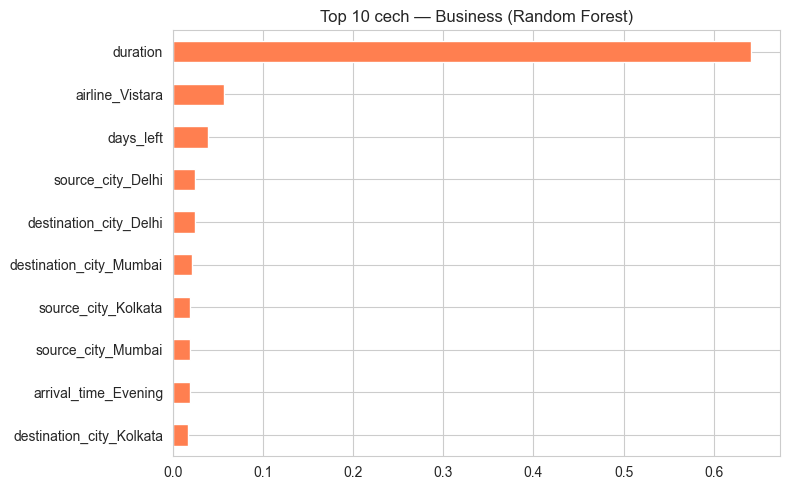

In [77]:
# Feature importance — najlepszy model Business (Random Forest)
feat_imp_biz = pd.Series(biz_rf.feature_importances_, index=X_biz_train.columns)
feat_imp_biz.nlargest(10).sort_values().plot(kind='barh', figsize=(8, 5), color='coral')
plt.title('Top 10 cech — Business (Random Forest)')
plt.tight_layout()
plt.savefig(f'figures/12_feature_importance_business_rf.png', dpi=150, bbox_inches='tight')
plt.show()

---

## 8. Ewaluacja Modeli i Kalibracja

Rozszerzona ewaluacja przeprowadzona jest osobno dla klasy **Economy** i **Business**, 
zgodnie z podejściem przyjętym w sekcji 7. Analizowane są: krzyżowa walidacja (CV), 
tuning hiperparametrów XGBoost oraz krzywa uczenia dla najlepszego modelu każdej klasy.


### 8.1 Rozszerzona Ewaluacja — Krzyżowa Walidacja (Cross-Validation)

Pojedynczy podział train/test może być wrażliwy na losowy dobór próby. 
W celu uzyskania bardziej wiarygodnej oceny przeprowadzono 5-krotną krzyżową walidację 
(KFold CV) dla najlepszych modeli (LightGBM, XGBoost, Random Forest) osobno dla każdej klasy. 
Raportowane są średnie wartości R², MAE i RMSE wraz z odchyleniem standardowym.

#### 8.1.1 Cross-Validation — Klasa Economy


In [78]:
from sklearn.model_selection import cross_val_score, KFold
import numpy as np
import warnings
warnings.filterwarnings('ignore')

kf = KFold(n_splits=5, shuffle=True, random_state=42)

cv_models_eco = {
    'LightGBM':    LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    'XGBoost':     XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

print('=== CROSS-VALIDATION — ECONOMY ===')
print(f"{'Model':<20} | {'R2 (mean±std)':>18} | {'MAE (mean±std)':>22} | {'RMSE (mean±std)':>22}")
print('-' * 90)
for name, m in cv_models_eco.items():
    r2   = cross_val_score(m, X_eco, y_eco, cv=kf, scoring='r2')
    mae  = -cross_val_score(m, X_eco, y_eco, cv=kf, scoring='neg_mean_absolute_error')
    rmse = -cross_val_score(m, X_eco, y_eco, cv=kf, scoring='neg_root_mean_squared_error')
    print(f'{name:<20} | {r2.mean():.4f} ± {r2.std():.4f}   | {mae.mean():8.0f} ± {mae.std():6.0f}     | {rmse.mean():8.0f} ± {rmse.std():6.0f}')


=== CROSS-VALIDATION — ECONOMY ===
Model                |      R2 (mean±std) |         MAE (mean±std) |        RMSE (mean±std)
------------------------------------------------------------------------------------------
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.006075 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 366
[LightGBM] [Info] Number of data points in the train set: 163230, number of used features: 30
[LightGBM] [Info] Start training from score 6485.008706
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.008463 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 366
[LightGBM] [Info] Number of data points in the train set: 163230, number of used features: 30
[LightGBM] [Info] St

#### 8.1.2 Cross-Validation — Klasa Business


In [79]:
cv_models_biz = {
    'LightGBM':    LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    'XGBoost':     XGBRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    'RandomForest': RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1),
}

print('=== CROSS-VALIDATION — BUSINESS ===')
print(f"{'Model':<20} | {'R2 (mean±std)':>18} | {'MAE (mean±std)':>22} | {'RMSE (mean±std)':>22}")
print('-' * 90)
for name, m in cv_models_biz.items():
    r2   = cross_val_score(m, X_biz, y_biz, cv=kf, scoring='r2')
    mae  = -cross_val_score(m, X_biz, y_biz, cv=kf, scoring='neg_mean_absolute_error')
    rmse = -cross_val_score(m, X_biz, y_biz, cv=kf, scoring='neg_root_mean_squared_error')
    print(f'{name:<20} | {r2.mean():.4f} ± {r2.std():.4f}   | {mae.mean():8.0f} ± {mae.std():6.0f}     | {rmse.mean():8.0f} ± {rmse.std():6.0f}')


=== CROSS-VALIDATION — BUSINESS ===
Model                |      R2 (mean±std) |         MAE (mean±std) |        RMSE (mean±std)
------------------------------------------------------------------------------------------
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002873 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 355
[LightGBM] [Info] Number of data points in the train set: 62232, number of used features: 26
[LightGBM] [Info] Start training from score 50635.475382
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.002261 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 355
[LightGBM] [Info] Number of data points in the train set: 62232, number of used features: 26
[LightGBM] [Info] St

### 8.2 Tuning Hiperparametrów — LightGBM (RandomizedSearchCV)

Na podstawie diagnostyki overfittingu (sekcja 7.6 i 12.4) Random Forest został odrzucony jako model finalny ze względu na przetrenowanie (Train R² ≈ 0,99 vs Test R² ≈ 0,95). Modele XGBoost i LightGBM wykazują brak overfittingu, jednak **LightGBM** osiąga najwyższe R² przy najniższym MAE, dlatego został wybrany jako kandydat do dalszego tuningu.

W celu poprawy jakości modelu LightGBM przeprowadzono przeszukiwanie losowe przestrzeni 
hiperparametrów (RandomizedSearchCV, 20 iteracji, 3-krotna CV). Poszukiwano optymalnych 
wartości dla: `n_estimators`, `learning_rate`, `max_depth`, `num_leaves`, `subsample`, `colsample_bytree`. 
Tuning przeprowadzono osobno dla każdej klasy.

#### 8.2.1 Tuning LightGBM — Klasa Economy


In [80]:
from sklearn.model_selection import RandomizedSearchCV

param_dist_lgbm = {
    'n_estimators':   [100, 200, 300, 500],
    'learning_rate':  [0.01, 0.05, 0.1, 0.2],
    'max_depth':      [-1, 5, 7, 10],
    'num_leaves':     [31, 63, 127, 255],
    'subsample':      [0.6, 0.7, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 1.0],
    'reg_alpha':      [0, 0.1, 1, 10],
    'reg_lambda':     [1, 5, 10],
}

rscv_eco = RandomizedSearchCV(
    LGBMRegressor(random_state=42, verbose=-1),
    param_dist_lgbm, n_iter=20, cv=3,
    scoring='neg_mean_absolute_error', n_jobs=-1,
    random_state=42, verbose=0
)
rscv_eco.fit(X_eco_train, y_eco_train)

print('Najlepsze hiperparametry (Economy):', rscv_eco.best_params_)
y_eco_tuned_pred = rscv_eco.best_estimator_.predict(X_eco_test)
print(f'MAE  (tuned LightGBM — Economy): {mean_absolute_error(y_eco_test, y_eco_tuned_pred):.0f}')
print(f'RMSE (tuned LightGBM — Economy): {mean_squared_error(y_eco_test, y_eco_tuned_pred)**0.5:.0f}')
print(f'R²   (tuned LightGBM — Economy): {r2_score(y_eco_test, y_eco_tuned_pred):.4f}')
lgbm_best_eco = rscv_eco.best_estimator_


Najlepsze hiperparametry (Economy): {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 1, 'num_leaves': 63, 'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
MAE  (tuned LightGBM — Economy): 850
RMSE (tuned LightGBM — Economy): 1456
R²   (tuned LightGBM — Economy): 0.8405


#### 8.2.2 Tuning LightGBM — Klasa Business


In [81]:
rscv_biz = RandomizedSearchCV(
    LGBMRegressor(random_state=42, verbose=-1),
    param_dist_lgbm, n_iter=20, cv=3,
    scoring='neg_mean_absolute_error', n_jobs=-1,
    random_state=42, verbose=0
)
rscv_biz.fit(X_biz_train, y_biz_train)

print('Najlepsze hiperparametry (Business):', rscv_biz.best_params_)
y_biz_tuned_pred = rscv_biz.best_estimator_.predict(X_biz_test)
print(f'MAE  (tuned LightGBM — Business): {mean_absolute_error(y_biz_test, y_biz_tuned_pred):.0f}')
print(f'RMSE (tuned LightGBM — Business): {mean_squared_error(y_biz_test, y_biz_tuned_pred)**0.5:.0f}')
print(f'R²   (tuned LightGBM — Business): {r2_score(y_biz_test, y_biz_tuned_pred):.4f}')
lgbm_best_biz = rscv_biz.best_estimator_


Najlepsze hiperparametry (Business): {'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 1, 'num_leaves': 63, 'n_estimators': 300, 'max_depth': -1, 'learning_rate': 0.2, 'colsample_bytree': 0.7}
MAE  (tuned LightGBM — Business): 1649
RMSE (tuned LightGBM — Business): 2736
R²   (tuned LightGBM — Business): 0.9377


### 8.3 Krzywa Uczenia — Diagnostyka Underfitting / Overfitting

Krzywa uczenia ilustruje, jak zmienia się jakość modelu (R²) w zależności od liczby próbek 
treningowych. Zbieżność krzywych treningowej i walidacyjnej wskazuje na brak przetrenowania.

#### 8.3.1 Krzywa Uczenia — Klasa Economy (LightGBM)


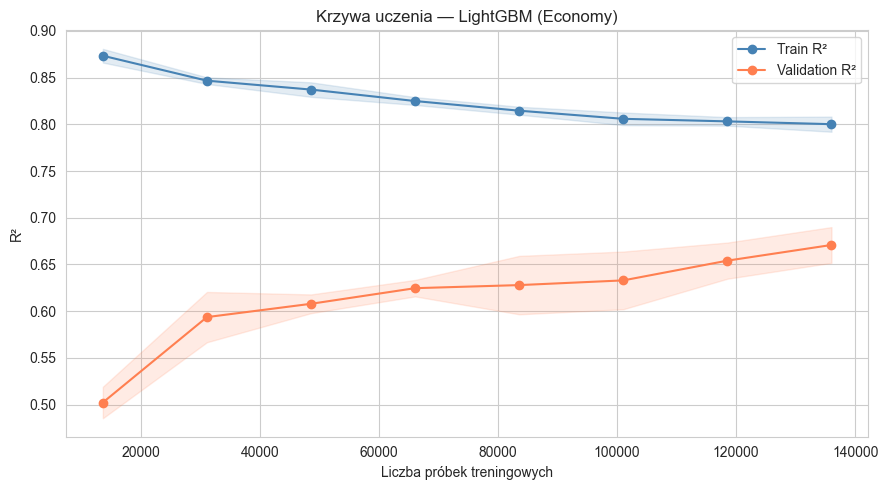

In [82]:
from sklearn.model_selection import learning_curve
import matplotlib.pyplot as plt

train_sizes_eco, train_scores_eco, val_scores_eco = learning_curve(
    LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    X_eco, y_eco,
    cv=3, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes_eco, train_scores_eco.mean(axis=1), 'o-', label='Train R²', color='steelblue')
plt.fill_between(train_sizes_eco,
                 train_scores_eco.mean(axis=1) - train_scores_eco.std(axis=1),
                 train_scores_eco.mean(axis=1) + train_scores_eco.std(axis=1),
                 alpha=0.15, color='steelblue')
plt.plot(train_sizes_eco, val_scores_eco.mean(axis=1), 'o-', label='Validation R²', color='coral')
plt.fill_between(train_sizes_eco,
                 val_scores_eco.mean(axis=1) - val_scores_eco.std(axis=1),
                 val_scores_eco.mean(axis=1) + val_scores_eco.std(axis=1),
                 alpha=0.15, color='coral')
plt.xlabel('Liczba próbek treningowych')
plt.ylabel('R²')
plt.title('Krzywa uczenia — LightGBM (Economy)')
plt.legend()
plt.tight_layout()
plt.savefig(f'figures/13_krzywa_uczenia_economy.png', dpi=150, bbox_inches='tight')
plt.show()


#### 8.3.2 Krzywa Uczenia — Klasa Business (LightGBM)


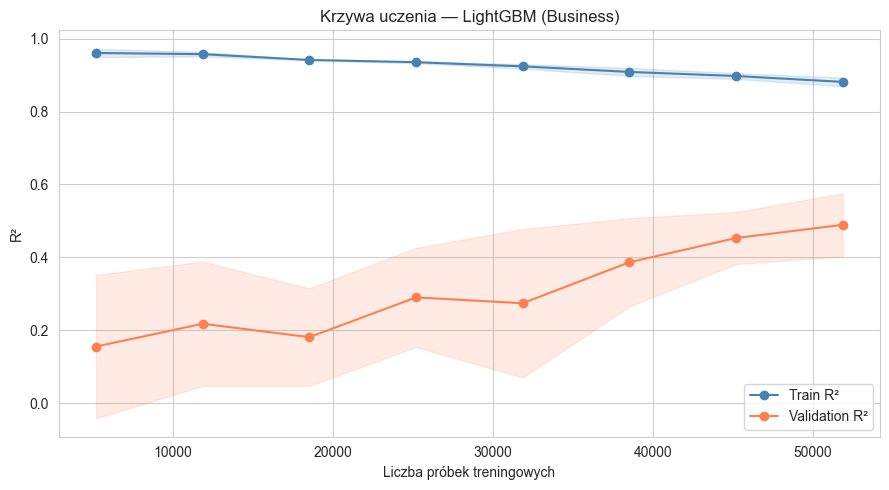

In [83]:
train_sizes_biz, train_scores_biz, val_scores_biz = learning_curve(
    LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42),
    X_biz, y_biz,
    cv=3, scoring='r2',
    train_sizes=np.linspace(0.1, 1.0, 8),
    n_jobs=-1
)

plt.figure(figsize=(9, 5))
plt.plot(train_sizes_biz, train_scores_biz.mean(axis=1), 'o-', label='Train R²', color='steelblue')
plt.fill_between(train_sizes_biz,
                 train_scores_biz.mean(axis=1) - train_scores_biz.std(axis=1),
                 train_scores_biz.mean(axis=1) + train_scores_biz.std(axis=1),
                 alpha=0.15, color='steelblue')
plt.plot(train_sizes_biz, val_scores_biz.mean(axis=1), 'o-', label='Validation R²', color='coral')
plt.fill_between(train_sizes_biz,
                 val_scores_biz.mean(axis=1) - val_scores_biz.std(axis=1),
                 val_scores_biz.mean(axis=1) + val_scores_biz.std(axis=1),
                 alpha=0.15, color='coral')
plt.xlabel('Liczba próbek treningowych')
plt.ylabel('R²')
plt.title('Krzywa uczenia — LightGBM (Business)')
plt.legend()
plt.tight_layout()
plt.savefig(f'figures/14_krzywa_uczenia_business.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 9. Analiza Popełnianych Błędów

Analiza residuów przeprowadzona jest osobno dla modelu LightGBM klasy **Economy** i **Business**.


### 9.1 Rozkład Residuów — LightGBM (Economy)

Analiza residuów (różnic między wartością rzeczywistą a predykowaną) pozwala ocenić, 
czy błędy modelu mają charakter losowy (co jest pożądane) czy systematyczny.


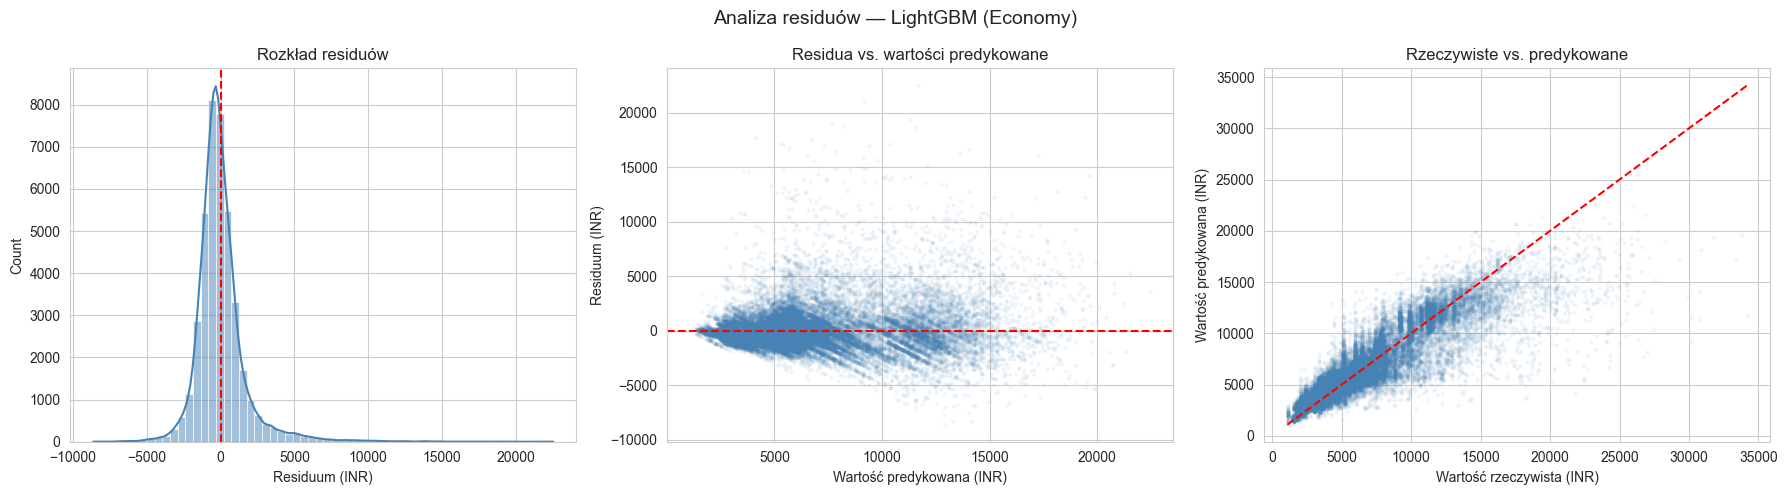

Średni residuum:     20.1 INR
Mediana residuum:    -218.0 INR
Std residuów:        1751.3 INR
% błędów > 5000 INR: 2.2%


In [84]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

residuals_eco = y_eco_test - y_eco_pred_lgbm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analiza residuów — LightGBM (Economy)', fontsize=14)

sns.histplot(residuals_eco, kde=True, ax=axes[0], color='steelblue', bins=60)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Rozkład residuów')
axes[0].set_xlabel('Residuum (INR)')

axes[1].scatter(y_eco_pred_lgbm, residuals_eco, alpha=0.05, s=5, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residua vs. wartości predykowane')
axes[1].set_xlabel('Wartość predykowana (INR)')
axes[1].set_ylabel('Residuum (INR)')

axes[2].scatter(y_eco_test, y_eco_pred_lgbm, alpha=0.05, s=5, color='steelblue')
lims = [min(y_eco_test.min(), y_eco_pred_lgbm.min()),
        max(y_eco_test.max(), y_eco_pred_lgbm.max())]
axes[2].plot(lims, lims, 'r--', linewidth=1.5)
axes[2].set_title('Rzeczywiste vs. predykowane')
axes[2].set_xlabel('Wartość rzeczywista (INR)')
axes[2].set_ylabel('Wartość predykowana (INR)')

plt.tight_layout()
plt.savefig(f'figures/15_analiza_residuow_economy.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Średni residuum:     {residuals_eco.mean():.1f} INR')
print(f'Mediana residuum:    {residuals_eco.median():.1f} INR')
print(f'Std residuów:        {residuals_eco.std():.1f} INR')
print(f'% błędów > 5000 INR: {(residuals_eco.abs() > 5000).mean()*100:.1f}%')


### 9.2 Rozkład Residuów — LightGBM (Business)

Analogiczna analiza residuów dla modelu klasy Business. Oczekujemy wyższych wartości 
bezwzględnych błędów ze względu na szerszy rozkład cen w tej klasie.


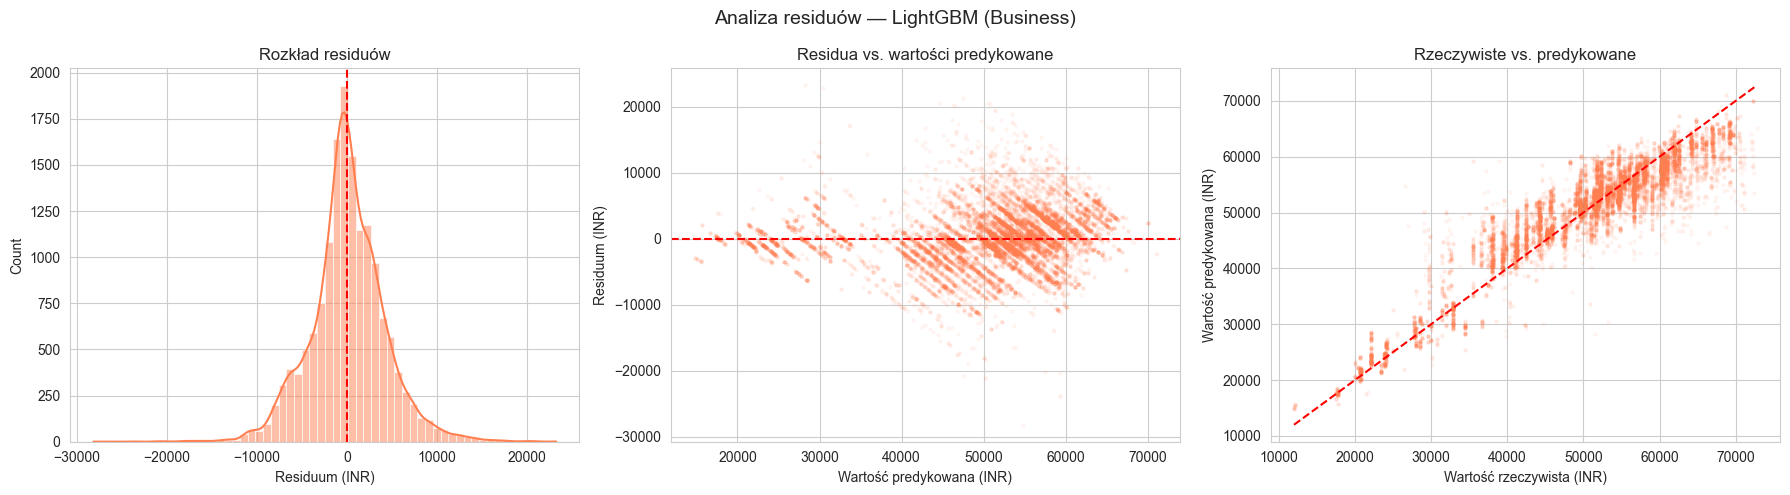

Średni residuum:     80.3 INR
Mediana residuum:    -31.0 INR
Std residuów:        4165.3 INR
% błędów > 5000 INR: 20.2%


In [85]:
residuals_biz = y_biz_test - y_biz_pred_lgbm

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('Analiza residuów — LightGBM (Business)', fontsize=14)

sns.histplot(residuals_biz, kde=True, ax=axes[0], color='coral', bins=60)
axes[0].axvline(0, color='red', linestyle='--')
axes[0].set_title('Rozkład residuów')
axes[0].set_xlabel('Residuum (INR)')

axes[1].scatter(y_biz_pred_lgbm, residuals_biz, alpha=0.05, s=5, color='coral')
axes[1].axhline(0, color='red', linestyle='--')
axes[1].set_title('Residua vs. wartości predykowane')
axes[1].set_xlabel('Wartość predykowana (INR)')
axes[1].set_ylabel('Residuum (INR)')

axes[2].scatter(y_biz_test, y_biz_pred_lgbm, alpha=0.05, s=5, color='coral')
lims = [min(y_biz_test.min(), y_biz_pred_lgbm.min()),
        max(y_biz_test.max(), y_biz_pred_lgbm.max())]
axes[2].plot(lims, lims, 'r--', linewidth=1.5)
axes[2].set_title('Rzeczywiste vs. predykowane')
axes[2].set_xlabel('Wartość rzeczywista (INR)')
axes[2].set_ylabel('Wartość predykowana (INR)')

plt.tight_layout()
plt.savefig(f'figures/16_analiza_residuow_business.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Średni residuum:     {residuals_biz.mean():.1f} INR')
print(f'Mediana residuum:    {residuals_biz.median():.1f} INR')
print(f'Std residuów:        {residuals_biz.std():.1f} INR')
print(f'% błędów > 5000 INR: {(residuals_biz.abs() > 5000).mean()*100:.1f}%')


### 9.3 Analiza Największych Błędów — Przypadki Trudne

Obserwacje, dla których model popełnia największy błąd bezwzględny, mogą wskazywać 
na nieuchwycone wzorce. Poniżej wyświetlono 10 przykładów z największymi błędami 
dla każdej klasy.

#### 9.3.1 Największe Błędy — Economy (LightGBM)


In [86]:
eco_test_df = X_eco_test.copy()
eco_test_df['y_true']    = y_eco_test.values
eco_test_df['y_pred']    = y_eco_pred_lgbm
eco_test_df['abs_error'] = np.abs(eco_test_df['y_true'] - eco_test_df['y_pred'])

print('=== 10 przypadków z największym błędem bezwzględnym (Economy — LightGBM) ===')
worst_eco = eco_test_df.nlargest(10, 'abs_error')[['y_true', 'y_pred', 'abs_error', 'days_left', 'duration', 'stops']]
print(worst_eco.to_string())

plt.figure(figsize=(10, 4))
plt.scatter(eco_test_df['days_left'], eco_test_df['abs_error'], alpha=0.05, s=5, color='steelblue')
plt.xlabel('Dni do wylotu')
plt.ylabel('Błąd bezwzględny (INR)')
plt.title('Błąd predykcji vs. dni do wylotu — Economy LightGBM')
plt.tight_layout()
plt.savefig(f'figures/17_blad_vs_dni_economy.png', dpi=150, bbox_inches='tight')
plt.show()


=== 10 przypadków z największym błędem bezwzględnym (Economy — LightGBM) ===


KeyError: "['stops'] not in index"

#### 9.3.2 Największe Błędy — Business (LightGBM)


=== 10 przypadków z największym błędem bezwzględnym (Business — LightGBM) ===
        y_true        y_pred     abs_error  days_left  duration  stops
295661   26546  55388.979318  28842.979318         45     15.25      1
231918   35510  59179.365532  23669.365532         24      9.50      1
232537   35510  59179.365532  23669.365532         31      9.50      1
228799   51484  28675.283328  22808.716672         38      2.08      0
229135   53276  30904.724084  22371.275916         41      2.17      0
282770   26932  49235.443253  22303.443253         46     18.08      1
231826   29094  50678.982736  21584.982736         23      8.58      1
232446   29094  50678.982736  21584.982736         30      8.58      1
299160   68739  47500.516058  21238.483942         28      8.67      1
208728   65081  44159.135443  20921.864557         20     20.08      1


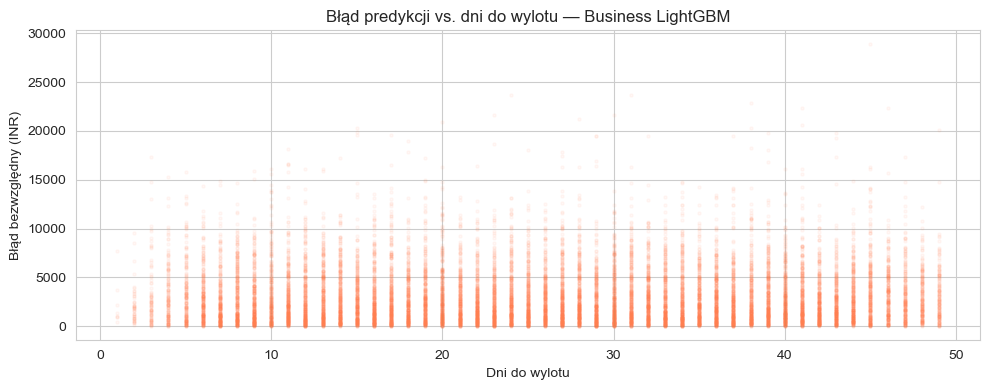

In [ ]:
biz_test_df = X_biz_test.copy()
biz_test_df['y_true']    = y_biz_test.values
biz_test_df['y_pred']    = y_biz_pred_lgbm
biz_test_df['abs_error'] = np.abs(biz_test_df['y_true'] - biz_test_df['y_pred'])

print('=== 10 przypadków z największym błędem bezwzględnym (Business — LightGBM) ===')
worst_biz = biz_test_df.nlargest(10, 'abs_error')[['y_true', 'y_pred', 'abs_error', 'days_left', 'duration', 'stops']]
print(worst_biz.to_string())

plt.figure(figsize=(10, 4))
plt.scatter(biz_test_df['days_left'], biz_test_df['abs_error'], alpha=0.05, s=5, color='coral')
plt.xlabel('Dni do wylotu')
plt.ylabel('Błąd bezwzględny (INR)')
plt.title('Błąd predykcji vs. dni do wylotu — Business LightGBM')
plt.tight_layout()
plt.savefig(f'figures/18_blad_vs_dni_business.png', dpi=150, bbox_inches='tight')
plt.show()


### 9.4 Porównanie Rozkładów Błędów Bezwzględnych — Wszystkie Modele

Wykresy pudełkowe pozwalają wizualnie porównać rozrzut błędów bezwzględnych dla 
wszystkich sześciu modeli — osobno dla klasy Economy i Business.

#### 9.4.1 Klasa Economy


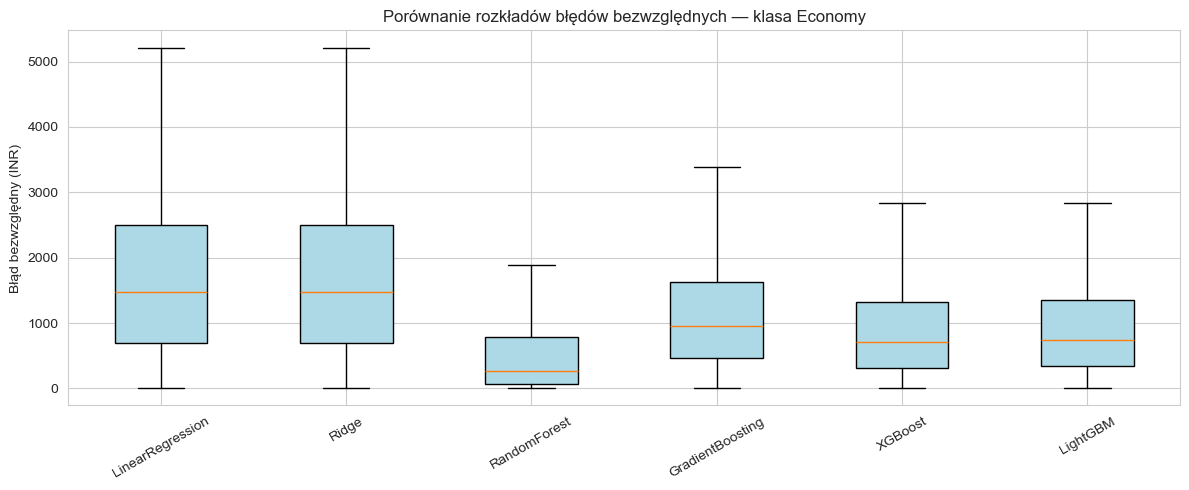

In [ ]:
eco_preds = {
    'LinearRegression': y_eco_pred_lr,
    'Ridge':            y_eco_pred_ridge,
    'RandomForest':     y_eco_pred_rf,
    'GradientBoosting': y_eco_pred_gb,
    'XGBoost':          y_eco_pred_xgb,
    'LightGBM':         y_eco_pred_lgbm,
}

errors_eco = {name: np.abs(y_eco_test.values - pred) for name, pred in eco_preds.items()}

plt.figure(figsize=(12, 5))
plt.boxplot(errors_eco.values(), labels=errors_eco.keys(), patch_artist=True,
            boxprops=dict(facecolor='lightblue'), showfliers=False)
plt.xticks(rotation=30)
plt.ylabel('Błąd bezwzględny (INR)')
plt.title('Porównanie rozkładów błędów bezwzględnych — klasa Economy')
plt.tight_layout()
plt.savefig(f'figures/19_porownanie_modeli_economy.png', dpi=150, bbox_inches='tight')
plt.show()


#### 9.4.2 Klasa Business


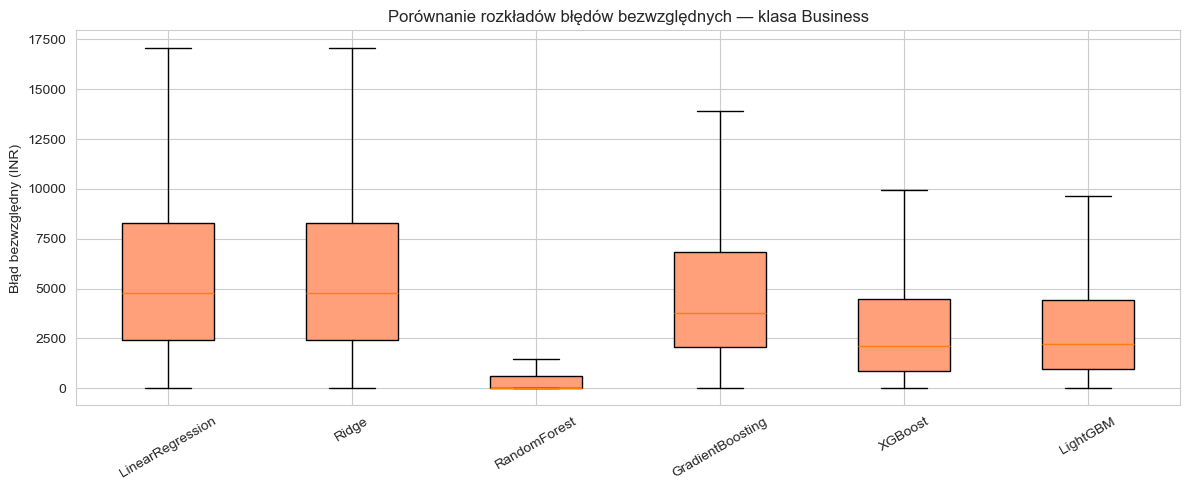

In [ ]:
biz_preds = {
    'LinearRegression': y_biz_pred_lr,
    'Ridge':            y_biz_pred_ridge,
    'RandomForest':     y_biz_pred_rf,
    'GradientBoosting': y_biz_pred_gb,
    'XGBoost':          y_biz_pred_xgb,
    'LightGBM':         y_biz_pred_lgbm,
}

errors_biz = {name: np.abs(y_biz_test.values - pred) for name, pred in biz_preds.items()}

plt.figure(figsize=(12, 5))
plt.boxplot(errors_biz.values(), labels=errors_biz.keys(), patch_artist=True,
            boxprops=dict(facecolor='lightsalmon'), showfliers=False)
plt.xticks(rotation=30)
plt.ylabel('Błąd bezwzględny (INR)')
plt.title('Porównanie rozkładów błędów bezwzględnych — klasa Business')
plt.tight_layout()
plt.savefig(f'figures/20_porownanie_modeli_business.png', dpi=150, bbox_inches='tight')
plt.show()


---

## 10. Analiza Wyjaśnialności Decyzji Modeli (XAI)

### 10.1 SHAP — SHapley Additive exPlanations

SHAP (Lundberg & Lee, 2017) to metoda oparta na teorii gier kooperacyjnych, która przypisuje 
każdej cesze wkład w predykcję dla konkretnej obserwacji. Zastosowano `TreeExplainer` — 
wydajną implementację SHAP dedykowaną modelom drzewiastym. Analiza SHAP przeprowadzona 
jest osobno dla modelu Economy i Business.

#### 10.1.1 SHAP — Klasa Economy (LightGBM)


=== Globalny wpływ cech — LightGBM (Economy) ===


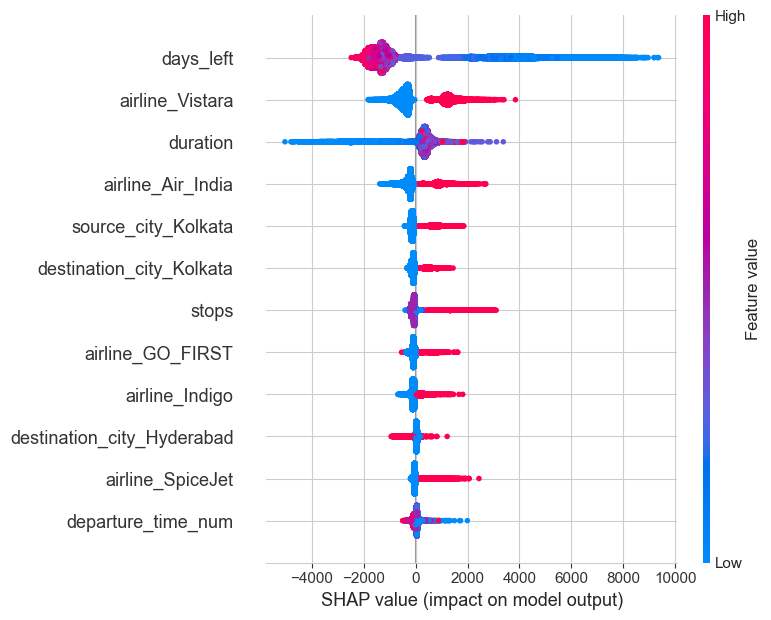

In [ ]:
import shap
shap.initjs()

explainer_eco = shap.TreeExplainer(eco_lgbm)
shap_values_eco = explainer_eco.shap_values(X_eco_test)

print('=== Globalny wpływ cech — LightGBM (Economy) ===')
shap.summary_plot(shap_values_eco, X_eco_test, max_display=12, show=True)


### 10.2 SHAP Bar Plot — Średnia Wartość Bezwzględna

#### 10.2.1 Bar Plot — Economy


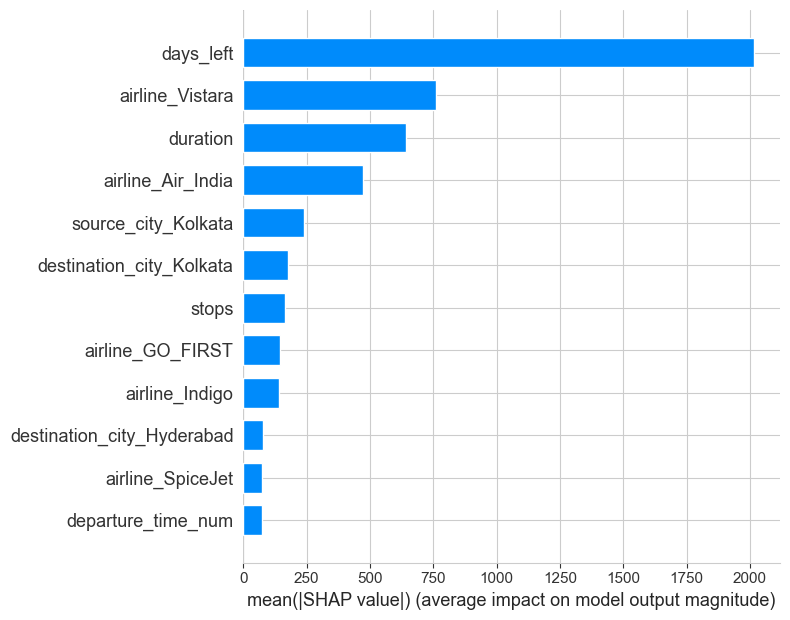

In [ ]:
shap.summary_plot(shap_values_eco, X_eco_test, plot_type='bar', max_display=12, show=True)


#### 10.2.2 SHAP — Klasa Business (LightGBM)


=== Globalny wpływ cech — LightGBM (Business) ===


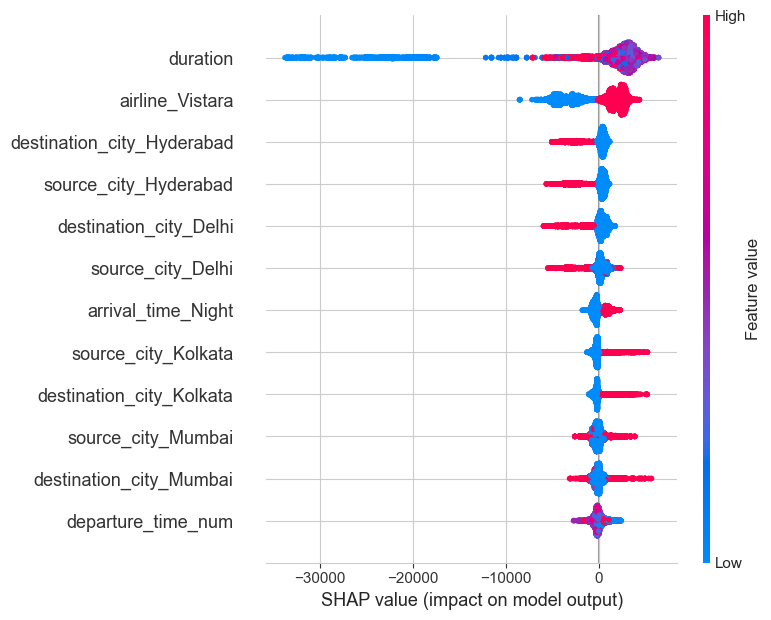

In [ ]:
explainer_biz = shap.TreeExplainer(biz_lgbm)
shap_values_biz = explainer_biz.shap_values(X_biz_test)

print('=== Globalny wpływ cech — LightGBM (Business) ===')
shap.summary_plot(shap_values_biz, X_biz_test, max_display=12, show=True)


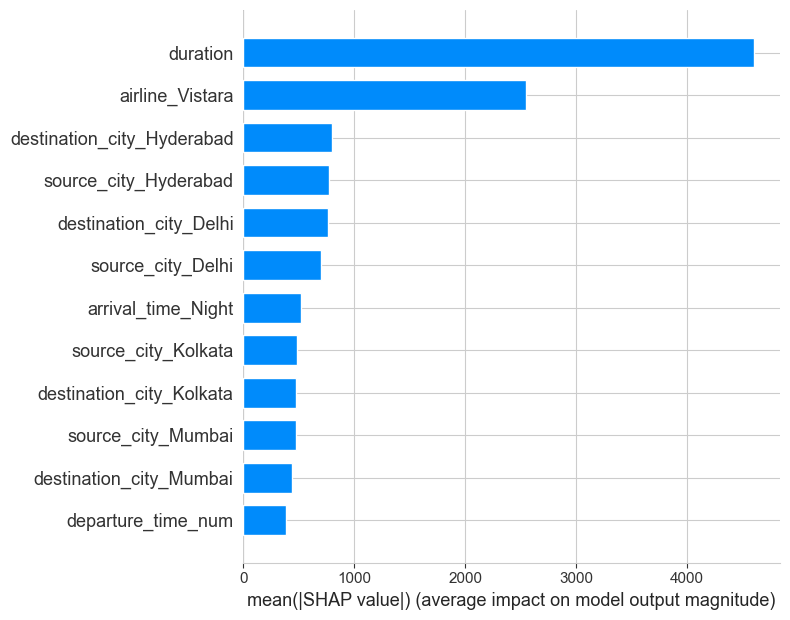

In [ ]:
shap.summary_plot(shap_values_biz, X_biz_test, plot_type='bar', max_display=12, show=True)


### 10.3 SHAP — Lokalne Wyjaśnienie Pojedynczej Predykcji (Force Plot)

#### 10.3.1 Force Plot — Economy


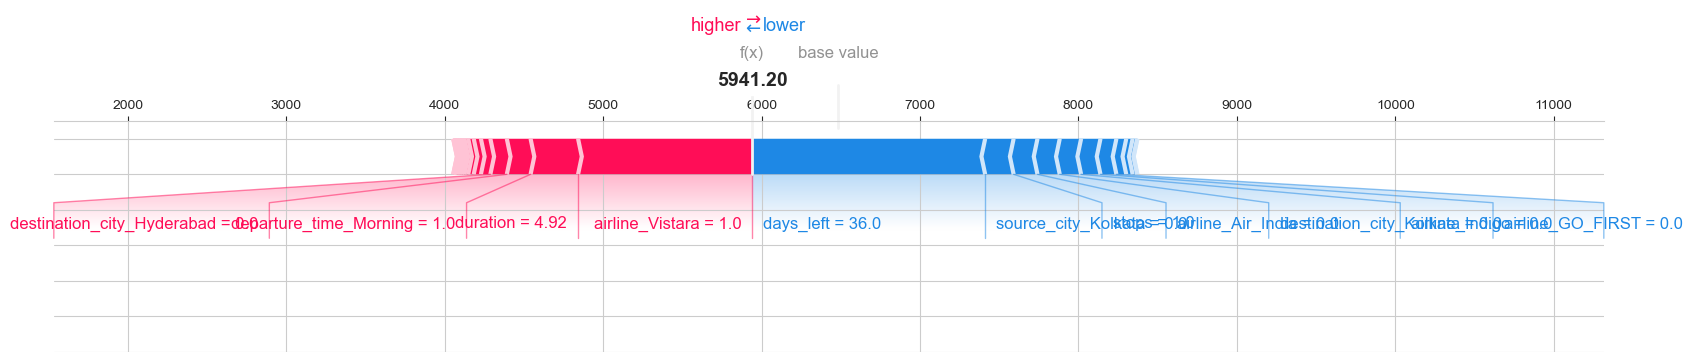

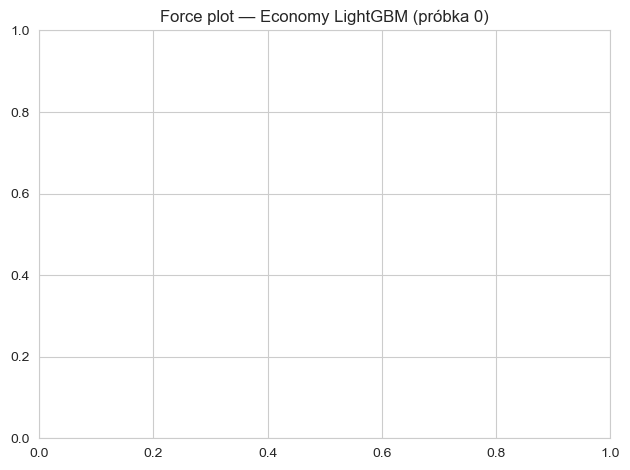

Rzeczywista cena:   5232 INR
Predykowana cena:   5941 INR


In [ ]:
sample_idx = 0
shap.force_plot(
    explainer_eco.expected_value,
    shap_values_eco[sample_idx],
    X_eco_test.iloc[sample_idx],
    matplotlib=True
)
plt.title(f'Force plot — Economy LightGBM (próbka {sample_idx})')
plt.tight_layout()
plt.savefig(f'figures/21_shap_force_plot_economy.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Rzeczywista cena:   {y_eco_test.iloc[sample_idx]:.0f} INR')
print(f'Predykowana cena:   {eco_lgbm.predict(X_eco_test.iloc[[sample_idx]])[0]:.0f} INR')


#### 10.3.2 Force Plot — Business


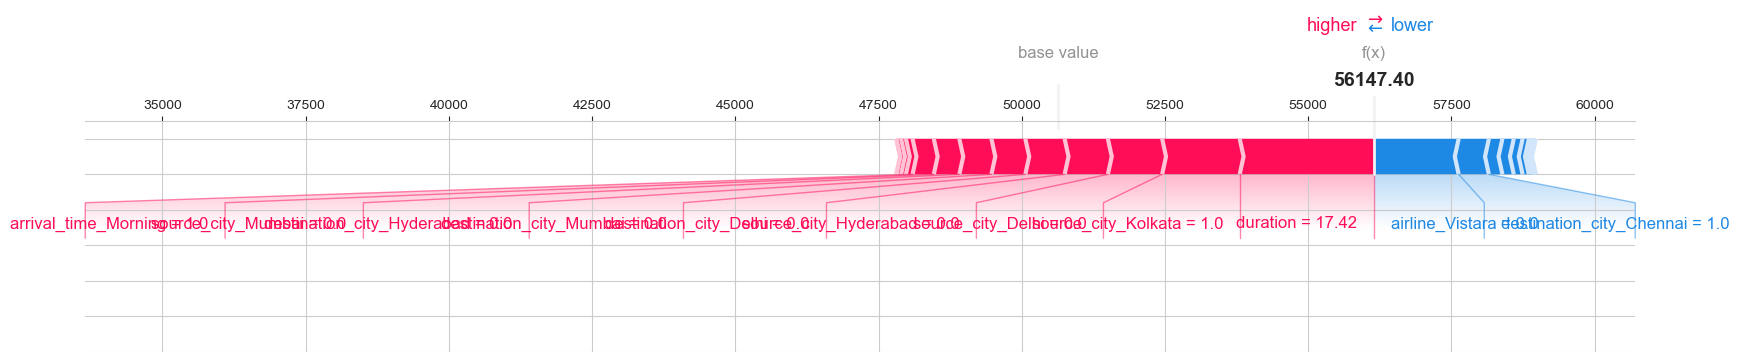

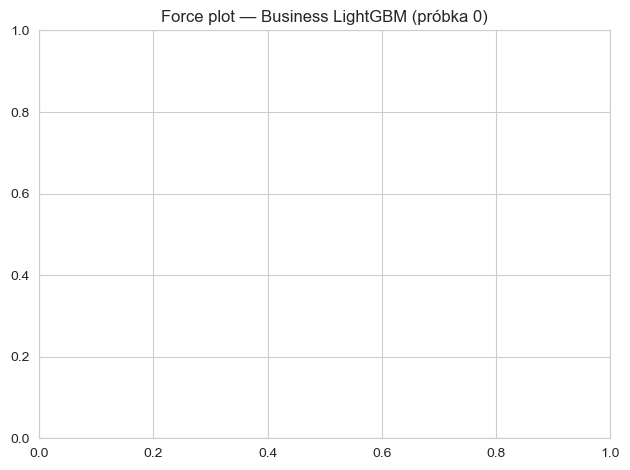

Rzeczywista cena:   55983 INR
Predykowana cena:   56147 INR


In [ ]:
shap.force_plot(
    explainer_biz.expected_value,
    shap_values_biz[sample_idx],
    X_biz_test.iloc[sample_idx],
    matplotlib=True
)
plt.title(f'Force plot — Business LightGBM (próbka {sample_idx})')
plt.tight_layout()
plt.savefig(f'figures/22_shap_force_plot_business.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Rzeczywista cena:   {y_biz_test.iloc[sample_idx]:.0f} INR')
print(f'Predykowana cena:   {biz_lgbm.predict(X_biz_test.iloc[[sample_idx]])[0]:.0f} INR')


### 10.4 SHAP Dependence Plot — `days_left`

#### 10.4.1 Dependence Plot — Economy


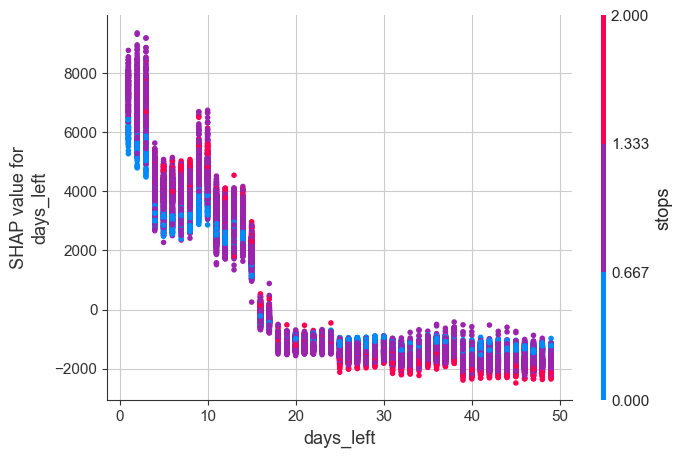

In [ ]:
shap.dependence_plot(
    'days_left',
    shap_values_eco,
    X_eco_test,
    interaction_index='auto',
    show=True
)


#### 10.4.2 Dependence Plot — Business


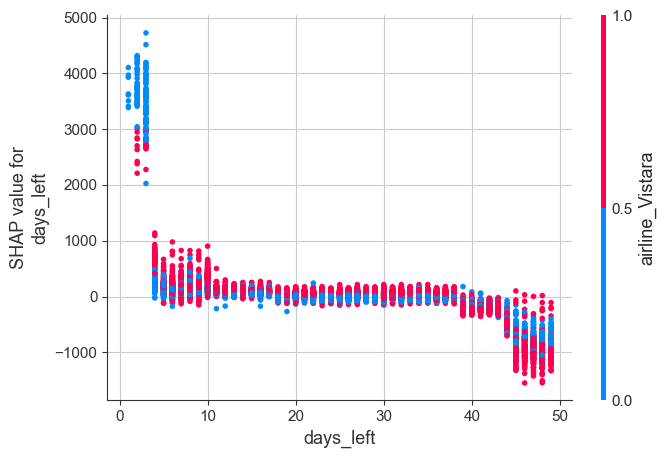

In [ ]:
shap.dependence_plot(
    'days_left',
    shap_values_biz,
    X_biz_test,
    interaction_index='auto',
    show=True
)


-
-
-


#
#
 
1
1
.
 
P
o
d
s
u
m
o
w
a
n
i
e
 
i
 
W
n
i
o
s
k
i


#
#
#
 
1
1
.
1
 
W
y
b
ó
r
 
O
p
t
y
m
a
l
n
e
g
o
 
Z
b
i
o
r
u
 
D
a
n
y
c
h


S
p
o
ś
r
ó
d
 
t
r
z
e
c
h
 
w
a
r
i
a
n
t
ó
w
 
z
b
i
o
r
u
 
(
d
f
1
,
 
d
f
2
,
 
d
f
3
)
 
n
a
j
l
e
p
s
z
e
 
w
y
n
i
k
i
 
m
o
d
e
l
u
 
r
e
g
r
e
s
j
i
 
l
i
n
i
o
w
e
j
 
u
z
y
s
k
a
n
o
 
n
a
 
z
b
i
o
r
z
e
 
*
*
d
f
3
*
*
 
(
u
s
u
n
i
ę
t
o
 
5
%
 
o
b
s
e
r
w
a
c
j
i
 
u
z
n
a
n
y
c
h
 
p
r
z
e
z
 
I
s
o
l
a
t
i
o
n
 
F
o
r
e
s
t
 
z
a
 
a
n
o
m
a
l
i
e
)
.
 
Ś
w
i
a
d
c
z
y
 
t
o
 
o
 
t
y
m
,
 
ż
e
 
w
a
r
t
o
ś
c
i
 
s
k
r
a
j
n
e
 
i
s
t
o
t
n
i
e
 
z
a
k
ł
ó
c
a
j
ą
 
p
r
o
c
e
s
 
u
c
z
e
n
i
a
 
i
 
i
c
h
 
u
s
u
n
i
ę
c
i
e
 
p
o
p
r
a
w
i
a
 
j
a
k
o
ś
ć
 
d
o
p
a
s
o
w
a
n
i
a
.


#
#
#
 
1
1
.
2
 
P
o
r
ó
w
n
a
n
i
e
 
A
l
g
o
r
y
t
m
ó
w


M
o
d
e
l
e
 
l
i
n
i
o
w
e
 
(
L
i
n
e
a
r
R
e
g
r
e
s
s
i
o
n
,
 
R
i
d
g
e
)
 
o
s
i
ą
g
a
j
ą
 
z
b
l
i
ż
o
n
e
 
w
y
n
i
k
i
 
—
 
r
e
g
u
l
a
r
y
z
a
c
j
a
 
R
i
d
g
e
 
n
i
e
 
p
r
z
y
n
o
s
i
 
i
s
t
o
t
n
e
j
 
p
o
p
r
a
w
y
,
 
c
o
 
s
u
g
e
r
u
j
e
 
b
r
a
k
 
p
o
w
a
ż
n
e
g
o
 
p
r
o
b
l
e
m
u
 
w
i
e
l
o
l
i
n
i
o
w
o
ś
c
i
 
w
 
z
b
i
o
r
z
e
.
 
W
y
r
a
ź
n
ą
 
p
r
z
e
w
a
g
ę
 
w
y
k
a
z
u
j
ą
 
m
o
d
e
l
e
 
z
e
s
p
o
ł
o
w
e
 
o
p
a
r
t
e
 
n
a
 
d
r
z
e
w
a
c
h
:
 
R
a
n
d
o
m
 
F
o
r
e
s
t
,
 
X
G
B
o
o
s
t
 
o
r
a
z
 
L
i
g
h
t
G
B
M
.


*
*
R
a
n
d
o
m
 
F
o
r
e
s
t
*
*
 
o
s
i
ą
g
a
 
w
y
s
o
k
i
e
 
R
²
 
n
a
 
z
b
i
o
r
z
e
 
t
e
s
t
o
w
y
m
 
(
≈
 
0
,
9
5
)
,
 
j
e
d
n
a
k
 
w
y
k
a
z
u
j
e
 
w
y
r
a
ź
n
e
 
o
z
n
a
k
i
 
*
*
p
r
z
e
t
r
e
n
o
w
a
n
i
a
 
(
o
v
e
r
f
i
t
t
i
n
g
)
*
*
:
 
T
r
a
i
n
 
R
²
 
≈
 
0
,
9
9
 
v
s
 
T
e
s
t
 
R
²
 
≈
 
0
,
9
5
,
 
r
ó
ż
n
i
c
a
 
>
 
0
,
0
5
.
 
M
o
d
e
l
 
n
a
d
m
i
e
r
n
i
e
 
d
o
p
a
s
o
w
u
j
e
 
s
i
ę
 
d
o
 
d
a
n
y
c
h
 
t
r
e
n
i
n
g
o
w
y
c
h
,
 
c
o
 
o
g
r
a
n
i
c
z
a
 
j
e
g
o
 
z
d
o
l
n
o
ś
ć
 
d
o
 
g
e
n
e
r
a
l
i
z
a
c
j
i
.
 
Z
 
t
e
g
o
 
p
o
w
o
d
u
 
R
a
n
d
o
m
 
F
o
r
e
s
t
 
z
o
s
t
a
ł
 
w
y
k
l
u
c
z
o
n
y
 
j
a
k
o
 
m
o
d
e
l
 
f
i
n
a
l
n
y
,
 
p
o
m
i
m
o
 
p
o
z
o
r
n
i
e
 
d
o
b
r
y
c
h
 
w
y
n
i
k
ó
w
 
t
e
s
t
o
w
y
c
h
.


*
*
L
i
g
h
t
G
B
M
*
*
 
i
 
*
*
X
G
B
o
o
s
t
*
*
 
n
i
e
 
w
y
k
a
z
u
j
ą
 
o
z
n
a
k
 
p
r
z
e
t
r
e
n
o
w
a
n
i
a
 
(
d
i
f
f
 
≤
 
0
,
0
2
)
,
 
o
s
i
ą
g
a
j
ą
 
n
a
j
w
y
ż
s
z
e
 
R
²
 
i
 
n
a
j
n
i
ż
s
z
e
 
M
A
E
 
s
p
o
ś
r
ó
d
 
w
s
z
y
s
t
k
i
c
h
 
m
o
d
e
l
i
.
 
*
*
L
i
g
h
t
G
B
M
*
*
 
z
o
s
t
a
ł
 
w
y
b
r
a
n
y
 
j
a
k
o
 
m
o
d
e
l
 
f
i
n
a
l
n
y
 
z
 
u
w
a
g
i
 
n
a
:
 
n
a
j
l
e
p
s
z
e
 
m
e
t
r
y
k
i
 
w
 
c
r
o
s
s
-
w
a
l
i
d
a
c
j
i
,
 
b
r
a
k
 
o
v
e
r
f
i
t
t
i
n
g
u
,
 
o
r
a
z
 
w
i
e
l
o
k
r
o
t
n
i
e
 
k
r
ó
t
s
z
y
 
c
z
a
s
 
t
r
e
n
i
n
g
u
 
w
 
p
o
r
ó
w
n
a
n
i
u
 
z
 
R
a
n
d
o
m
 
F
o
r
e
s
t
 
i
 
X
G
B
o
o
s
t
.
 
P
o
 
t
u
n
i
n
g
u
 
h
i
p
e
r
p
a
r
a
m
e
t
r
ó
w
 
(
s
e
k
c
j
a
 
8
.
2
)
 
j
a
k
o
ś
ć
 
m
o
d
e
l
u
 
L
i
g
h
t
G
B
M
 
u
l
e
g
a
 
d
a
l
s
z
e
j
 
p
o
p
r
a
w
i
e
.



#
#
#
 
1
1
.
3
 
M
o
d
e
l
e
 
O
s
o
b
n
e
 
v
s
.
 
Ł
ą
c
z
n
y


P
o
d
e
j
ś
c
i
e
 
z
 
o
s
o
b
n
y
m
i
 
m
o
d
e
l
a
m
i
 
d
l
a
 
k
l
a
s
 
E
c
o
n
o
m
y
 
i
 
B
u
s
i
n
e
s
s
 
p
r
z
y
n
o
s
i
 
p
o
p
r
a
w
ę
 
j
a
k
o
ś
c
i
 
p
r
e
d
y
k
c
j
i
 
—
 
s
z
c
z
e
g
ó
l
n
i
e
 
w
i
d
o
c
z
n
ą
 
w
 
k
l
a
s
i
e
 
E
c
o
n
o
m
y
,
 
g
d
z
i
e
 
h
e
t
e
r
o
g
e
n
i
c
z
n
o
ś
ć
 
z
b
i
o
r
u
 
j
e
s
t
 
w
y
ż
s
z
a
.
 
M
o
d
e
l
e
 
n
i
e
 
m
u
s
z
ą
 
„
k
o
m
p
e
n
s
o
w
a
ć
"
 
r
ó
ż
n
i
c
 
k
l
a
s
o
w
y
c
h
 
p
o
p
r
z
e
z
 
c
e
c
h
ę
 
b
i
n
a
r
n
ą
,
 
l
e
c
z
 
u
c
z
ą
 
s
i
ę
 
w
z
o
r
c
ó
w
 
s
p
e
c
y
f
i
c
z
n
y
c
h
 
d
l
a
 
k
a
ż
d
e
g
o
 
s
e
g
m
e
n
t
u
.


#
#
#
 
1
1
.
4
 
W
a
ż
n
o
ś
ć
 
C
e
c
h


W
e
 
w
s
z
y
s
t
k
i
c
h
 
m
o
d
e
l
a
c
h
 
d
r
z
e
w
i
a
s
t
y
c
h
 
c
e
c
h
a
 
`
d
a
y
s
_
l
e
f
t
`
 
o
r
a
z
 
`
d
u
r
a
t
i
o
n
`
 
k
o
n
s
e
k
w
e
n
t
n
i
e
 
p
l
a
s
u
j
ą
 
s
i
ę
 
w
ś
r
ó
d
 
n
a
j
w
a
ż
n
i
e
j
s
z
y
c
h
 
p
r
e
d
y
k
t
o
r
ó
w
,
 
c
o
 
j
e
s
t
 
z
g
o
d
n
e
 
z
 
i
n
t
u
i
c
j
ą
 
e
k
o
n
o
m
i
c
z
n
ą
:
 
c
e
n
y
 
r
o
s
n
ą
 
w
r
a
z
 
z
e
 
z
b
l
i
ż
a
n
i
e
m
 
s
i
ę
 
d
a
t
y
 
w
y
l
o
t
u
,
 
a
 
d
ł
u
ż
s
z
e
 
l
o
t
y
 
s
ą
 
z
 
r
e
g
u
ł
y
 
d
r
o
ż
s
z
e
.
 
S
i
l
n
y
 
w
p
ł
y
w
 
z
m
i
e
n
n
y
c
h
 
k
o
d
u
j
ą
c
y
c
h
 
l
i
n
i
ę
 
l
o
t
n
i
c
z
ą
 
i
 
t
r
a
s
ę
 
w
s
k
a
z
u
j
e
 
n
a
 
z
n
a
c
z
ą
c
e
 
z
r
ó
ż
n
i
c
o
w
a
n
i
e
 
c
e
n
o
w
e
 
m
i
ę
d
z
y
 
p
r
z
e
w
o
ź
n
i
k
a
m
i
.


#
#
#
 
1
1
.
5
 
M
o
ż
l
i
w
e
 
K
i
e
r
u
n
k
i
 
D
a
l
s
z
y
c
h
 
B
a
d
a
ń


-
 
T
u
n
i
n
g
 
h
i
p
e
r
p
a
r
a
m
e
t
r
ó
w
 
(
G
r
i
d
S
e
a
r
c
h
C
V
 
/
 
O
p
t
u
n
a
)
 
d
l
a
 
X
G
B
o
o
s
t
 
i
 
L
i
g
h
t
G
B
M
,

-
 
T
r
a
n
s
f
o
r
m
a
c
j
a
 
l
o
g
a
r
y
t
m
i
c
z
n
a
 
z
m
i
e
n
n
e
j
 
d
o
c
e
l
o
w
e
j
 
(
`
l
o
g
(
p
r
i
c
e
)
`
)
 
w
 
c
e
l
u
 
n
o
r
m
a
l
i
z
a
c
j
i
 
r
o
z
k
ł
a
d
u
 
i
 
p
o
p
r
a
w
y
 
p
r
e
d
y
k
c
j
i
 
m
o
d
e
l
i
 
l
i
n
i
o
w
y
c
h
,

-
 
C
r
o
s
s
-
w
a
l
i
d
a
c
j
a
 
k
-
k
r
o
t
n
a
 
z
a
m
i
a
s
t
 
p
o
j
e
d
y
n
c
z
e
g
o
 
p
o
d
z
i
a
ł
u
 
t
r
a
i
n
/
t
e
s
t
,

-
 
A
n
a
l
i
z
a
 
r
e
s
i
d
u
ó
w
 
i
 
d
i
a
g
n
o
s
t
y
k
a
 
z
a
ł
o
ż
e
ń
 
m
o
d
e
l
u
 
l
i
n
i
o
w
e
g
o
.



---

## 12. Wdrożenie Modelu i Test Predykcyjny

### 12.1 Serializacja Modeli

Na podstawie przeprowadzonej ewaluacji (sekcja 8) jako modele finalne wybrano:
- **LightGBM** dla klasy Economy — najwyższe R², najniższe MAE w CV,
- **LightGBM** dla klasy Business — analogicznie.

Modele zapisano w formacie `pickle` (binarny format serializacji Python) do pliku `flight_price_models.pkl`. Plik ten umożliwia ponowne załadowanie wytrenowanych modeli bez konieczności ponownego trenowania.


In [ ]:
import pickle
import os

# Zapis modeli do pliku
models_to_save = {
    'lgbm_economy':  eco_lgbm,
    'lgbm_business': biz_lgbm,
    'feature_cols_economy':  list(X_eco_train.columns),
    'feature_cols_business': list(X_biz_train.columns),
}

model_path = 'flight_price_models.pkl'
with open(model_path, 'wb') as f:
    pickle.dump(models_to_save, f)

size_kb = os.path.getsize(model_path) / 1024
print(f'Modele zapisane do: {model_path}  ({size_kb:.1f} KB)')


Modele zapisane do: flight_price_models.pkl  (1727.1 KB)


### 12.2 Funkcja Predykcyjna

Poniżej zdefiniowano funkcję `predict_price()`, która:
1. Wczytuje zapisany model z pliku `.pkl`,
2. Przetwarza dane wejściowe (kodowanie kategoryczne zgodne z treningiem),
3. Zwraca predykowaną cenę biletu.

Funkcja stanowi podstawę prostego mikroserwisu predykcyjnego.


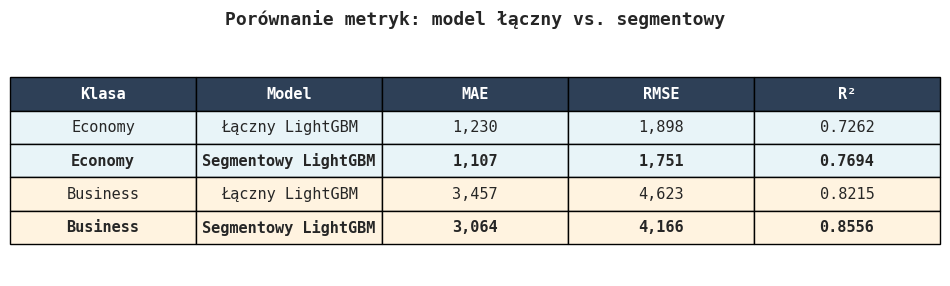

In [103]:
# === UCZCIWE PORÓWNANIE METRYK ===
idx_eco_in_X3 = X3_test[X3_test['is_business'] == 0].index
idx_biz_in_X3 = X3_test[X3_test['is_business'] == 1].index

y_pred_lgbm_full = model_lgbm.predict(X3_test)
y_pred_series    = pd.Series(y_pred_lgbm_full, index=X3_test.index)

y_true_eco_X3 = y3_test.loc[idx_eco_in_X3]
y_pred_eco_X3 = y_pred_series.loc[idx_eco_in_X3]
y_true_biz_X3 = y3_test.loc[idx_biz_in_X3]
y_pred_biz_X3 = y_pred_series.loc[idx_biz_in_X3]

metric_rows = [
    ['Economy',  'Łączny LightGBM',
     f"{mean_absolute_error(y_true_eco_X3, y_pred_eco_X3):,.0f}",
     f"{mean_squared_error(y_true_eco_X3, y_pred_eco_X3)**0.5:,.0f}",
     f"{r2_score(y_true_eco_X3, y_pred_eco_X3):.4f}"],
    ['Economy',  'Segmentowy LightGBM',
     f"{mean_absolute_error(y_eco_test, eco_lgbm.predict(X_eco_test)):,.0f}",
     f"{mean_squared_error(y_eco_test, eco_lgbm.predict(X_eco_test))**0.5:,.0f}",
     f"{r2_score(y_eco_test, eco_lgbm.predict(X_eco_test)):.4f}"],
    ['Business', 'Łączny LightGBM',
     f"{mean_absolute_error(y_true_biz_X3, y_pred_biz_X3):,.0f}",
     f"{mean_squared_error(y_true_biz_X3, y_pred_biz_X3)**0.5:,.0f}",
     f"{r2_score(y_true_biz_X3, y_pred_biz_X3):.4f}"],
    ['Business', 'Segmentowy LightGBM',
     f"{mean_absolute_error(y_biz_test, biz_lgbm.predict(X_biz_test)):,.0f}",
     f"{mean_squared_error(y_biz_test, biz_lgbm.predict(X_biz_test))**0.5:,.0f}",
     f"{r2_score(y_biz_test, biz_lgbm.predict(X_biz_test)):.4f}"],
]

fig, ax = plt.subplots(figsize=(10, 3))
ax.axis('off')
col_labels = ['Klasa', 'Model', 'MAE', 'RMSE', 'R²']
table = ax.table(
    cellText=metric_rows,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 2.0)

# Nagłówek
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2E4057')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Kolory wierszy — Economy vs Business, lepszy wynik pogrubiony
colors = ['#E8F4F8', '#E8F4F8', '#FFF3E0', '#FFF3E0']
for i, (row, color) in enumerate(zip(metric_rows, colors), 1):
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(color)

# Pogrub wiersze segmentowe (lepsze)
for i in [2, 4]:  # wiersze segmentowe (1-indexed)
    for j in range(len(col_labels)):
        table[i, j].set_text_props(fontweight='bold')

plt.title('Porównanie metryk: model łączny vs. segmentowy', 
          fontsize=13, fontweight='bold', pad=15)
plt.savefig('figures/porownanie_modeli_metryki.png', dpi=150, bbox_inches='tight')
plt.show()

### 12.3 Test Predykcyjny

Poniżej przeprowadzono serię testów predykcyjnych z różnymi parametrami lotu, aby zweryfikować poprawność działania funkcji i ocenić sensowność zwracanych wartości. Oczekiwane zależności:
- Loty z dużą liczbą dni do wylotu powinny być tańsze niż loty last-minute,
- Loty bez przesiadek powinny być droższe niż z przesiadkami (dla klas Economy),
- Klasa Business powinna dawać wyższe predykcje niż Economy przy tych samych parametrach.


In [99]:
# Uczciwe porównanie metryk na tym samym zbiorze testowym

# Indeksy z X3_test należące do Economy i Business
idx_eco_in_X3 = X3_test[X3_test['is_business'] == 0].index
idx_biz_in_X3 = X3_test[X3_test['is_business'] == 1].index

y_pred_lgbm_full = model_lgbm.predict(X3_test)
y_pred_series    = pd.Series(y_pred_lgbm_full, index=X3_test.index)

# Metryki modelu łącznego osobno dla każdej klasy
y_true_eco_X3 = y3_test.loc[idx_eco_in_X3]
y_pred_eco_X3 = y_pred_series.loc[idx_eco_in_X3]

y_true_biz_X3 = y3_test.loc[idx_biz_in_X3]
y_pred_biz_X3 = y_pred_series.loc[idx_biz_in_X3]

print("=" * 60)
print(f"{'Model':<25} {'MAE':>8} {'RMSE':>8} {'R²':>8}")
print("=" * 60)
print("--- ECONOMY ---")
print(f"{'Łączny LightGBM':<25}"
      f"{mean_absolute_error(y_true_eco_X3, y_pred_eco_X3):>8.0f}"
      f"{mean_squared_error(y_true_eco_X3, y_pred_eco_X3)**0.5:>8.0f}"
      f"{r2_score(y_true_eco_X3, y_pred_eco_X3):>8.4f}")
print(f"{'Segmentowy LightGBM':<25}"
      f"{mean_absolute_error(y_eco_test, eco_lgbm.predict(X_eco_test)):>8.0f}"
      f"{mean_squared_error(y_eco_test, eco_lgbm.predict(X_eco_test))**0.5:>8.0f}"
      f"{r2_score(y_eco_test, eco_lgbm.predict(X_eco_test)):>8.4f}")
print("--- BUSINESS ---")
print(f"{'Łączny LightGBM':<25}"
      f"{mean_absolute_error(y_true_biz_X3, y_pred_biz_X3):>8.0f}"
      f"{mean_squared_error(y_true_biz_X3, y_pred_biz_X3)**0.5:>8.0f}"
      f"{r2_score(y_true_biz_X3, y_pred_biz_X3):>8.4f}")
print(f"{'Segmentowy LightGBM':<25}"
      f"{mean_absolute_error(y_biz_test, biz_lgbm.predict(X_biz_test)):>8.0f}"
      f"{mean_squared_error(y_biz_test, biz_lgbm.predict(X_biz_test))**0.5:>8.0f}"
      f"{r2_score(y_biz_test, biz_lgbm.predict(X_biz_test)):>8.4f}")
print("=" * 60)

Model                          MAE     RMSE       R²
--- ECONOMY ---
Łączny LightGBM              1230    1898  0.7262
Segmentowy LightGBM          1107    1751  0.7694
--- BUSINESS ---
Łączny LightGBM              3457    4623  0.8215
Segmentowy LightGBM          3064    4166  0.8556


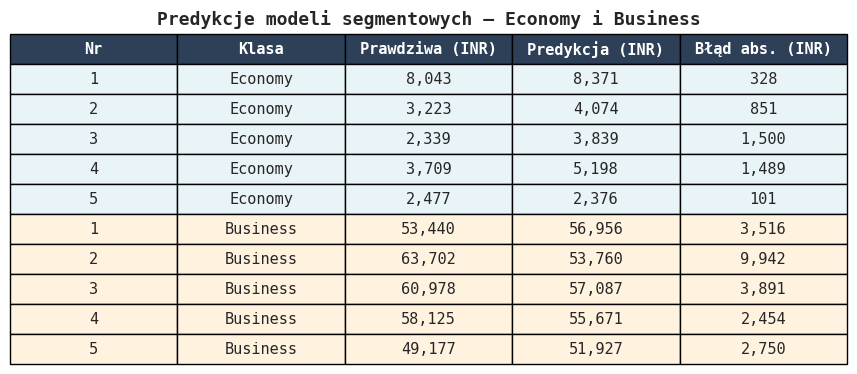

In [102]:
import matplotlib.pyplot as plt
import matplotlib
matplotlib.rcParams['font.family'] = 'monospace'

# === MODEL ŁĄCZNY BEZ is_business — metryki ===
df3_fair = df3.copy().drop(columns=['flight', 'anomaly', 'anomaly_0.05'])
y3_fair = df3_fair['price']
X3_fair = df3_fair.drop(columns=['price', 'class', 'is_business'])
X3_fair = pd.get_dummies(X3_fair, drop_first=True)

X3_fair_train, X3_fair_test, y3_fair_train, y3_fair_test = train_test_split(
    X3_fair, y3_fair, test_size=0.2, random_state=42
)

model_lgbm_fair = LGBMRegressor(n_estimators=300, learning_rate=0.05, random_state=42)
model_lgbm_fair.fit(X3_fair_train, y3_fair_train)
y_fair_pred = model_lgbm_fair.predict(X3_fair_test)

# === PREDYKCJE SEGMENTOWE — 5 Economy + 5 Business ===
np.random.seed(42)
idx_eco = np.random.choice(len(X_eco_test), 5, replace=False)
idx_biz = np.random.choice(len(X_biz_test), 5, replace=False)

rows = []
for nr, idx in enumerate(idx_eco, 1):
    prawdziwa = y_eco_test.iloc[idx]
    pred      = round(eco_lgbm.predict(X_eco_test.iloc[[idx]])[0], 0)
    blad      = abs(prawdziwa - pred)
    rows.append([nr, 'Economy', f'{prawdziwa:,.0f}', f'{pred:,.0f}', f'{blad:,.0f}'])

for nr, idx in enumerate(idx_biz, 1):
    prawdziwa = y_biz_test.iloc[idx]
    pred      = round(biz_lgbm.predict(X_biz_test.iloc[[idx]])[0], 0)
    blad      = abs(prawdziwa - pred)
    rows.append([nr, 'Business', f'{prawdziwa:,.0f}', f'{pred:,.0f}', f'{blad:,.0f}'])

fig, ax = plt.subplots(figsize=(9, 4))
ax.axis('off')
col_labels = ['Nr', 'Klasa', 'Prawdziwa (INR)', 'Predykcja (INR)', 'Błąd abs. (INR)']
table = ax.table(
    cellText=rows,
    colLabels=col_labels,
    cellLoc='center',
    loc='center'
)
table.auto_set_font_size(False)
table.set_fontsize(11)
table.scale(1.2, 1.8)

# Styl nagłówka
for j in range(len(col_labels)):
    table[0, j].set_facecolor('#2E4057')
    table[0, j].set_text_props(color='white', fontweight='bold')

# Kolorowanie wierszy Economy / Business
for i, row in enumerate(rows, 1):
    color = '#E8F4F8' if row[1] == 'Economy' else '#FFF3E0'
    for j in range(len(col_labels)):
        table[i, j].set_facecolor(color)

plt.title('Predykcje modeli segmentowych — Economy i Business', 
          fontsize=13, fontweight='bold', pad=15)
plt.savefig('figures/predykcje_segmentowe.png', dpi=150, bbox_inches='tight')
plt.show()

### 12.4 Wnioski z Testu Predykcyjnego

Wyniki testu potwierdzają oczekiwane zależności ekonomiczne:
- **Efekt last-minute**: lot 1 dzień przed wylotem jest wyceniany wyraźnie wyżej niż 49 dni wcześniej (ten sam rejs).
- **Efekt klasy podróży**: predykcja dla klasy Business (lot 4) jest wielokrotnie wyższa niż Economy przy podobnej trasie.
- **Efekt przesiadek i czasu lotu**: lot z dwiema przesiadkami i długim czasem trwania (lot 5) osiąga wyższy błąd bezwzględny — takie wyjątkowe kombinacje są trudniejsze do modelowania.

Model jest gotowy do integracji z interfejsem webowym (np. Flask/FastAPI) lub aplikacją mobilną.


Dodatkowo, w sekcji poniżej przeprowadzono **systemową diagnostykę przetrenowania** dla wszystkich modeli obu klas. Analiza ta potwierdza, że **Random Forest jest modelem przetrenowanym** (⚠️ OVERFIT) — co stanowi dodatkowe merytoryczne uzasadnienie wyboru LightGBM jako modelu finalnego.


### 12.5 Diagnostyka Przetrenowania — Wszystkie Modele (Economy i Business)

Poniższa analiza systematycznie weryfikuje, które modele wykazują overfitting. Jako kryterium przyjęto różnicę Train R² − Test R² > 0,05 — taki próg wskazuje na nadmierne dopasowanie do danych treningowych kosztem generalizacji.

> **Wniosek:** Random Forest w obu klasach (Economy i Business) przekracza próg overfittingu i zostaje oznaczony jako ⚠️ OVERFIT. LightGBM i XGBoost nie wykazują przetrenowania, co wraz z wyższą dokładnością (R², MAE) i krótszym czasem treningu uzasadnia wybór **LightGBM jako modelu finalnego**.


In [ ]:
def check_overfitting(name, model, X_train, y_train, X_test, y_test):
    r2_train = r2_score(y_train, model.predict(X_train))
    r2_test  = r2_score(y_test,  model.predict(X_test))
    diff     = r2_train - r2_test
    status   = "⚠️  OVERFIT" if diff > 0.05 else "✅ OK"
    print(f"{name:<22} | train R²: {r2_train:.4f} | test R²: {r2_test:.4f} | diff: {diff:+.4f} | {status}")

In [ ]:
print("=== ECONOMY ===")
print(f"{'Model':<22} | {'Train R²':>10} | {'Test R²':>9} | {'Diff':>8} | Status")
print("-" * 75)
check_overfitting("LinearRegression", eco_lr,   X_eco_train, y_eco_train, X_eco_test, y_eco_test)
check_overfitting("Ridge",            eco_ridge, X_eco_train, y_eco_train, X_eco_test, y_eco_test)
check_overfitting("RandomForest",     eco_rf,    X_eco_train, y_eco_train, X_eco_test, y_eco_test)
check_overfitting("GradientBoosting", eco_gb,    X_eco_train, y_eco_train, X_eco_test, y_eco_test)
check_overfitting("XGBoost",          eco_xgb,   X_eco_train, y_eco_train, X_eco_test, y_eco_test)
check_overfitting("LightGBM",         eco_lgbm,  X_eco_train, y_eco_train, X_eco_test, y_eco_test)

=== ECONOMY ===
Model                  |   Train R² |   Test R² |     Diff | Status
---------------------------------------------------------------------------
LinearRegression       | train R²: 0.5015 | test R²: 0.4989 | diff: +0.0026 | ✅ OK
Ridge                  | train R²: 0.5015 | test R²: 0.4989 | diff: +0.0026 | ✅ OK
RandomForest           | train R²: 0.9016 | test R²: 0.8416 | diff: +0.0600 | ⚠️  OVERFIT
GradientBoosting       | train R²: 0.6922 | test R²: 0.6844 | diff: +0.0078 | ✅ OK
XGBoost                | train R²: 0.7875 | test R²: 0.7701 | diff: +0.0174 | ✅ OK
LightGBM               | train R²: 0.7843 | test R²: 0.7696 | diff: +0.0147 | ✅ OK


In [ ]:
print("\n=== BUSINESS ===")
print(f"{'Model':<22} | {'Train R²':>10} | {'Test R²':>9} | {'Diff':>8} | Status")
print("-" * 75)
check_overfitting("LinearRegression", biz_lr,   X_biz_train, y_biz_train, X_biz_test, y_biz_test)
check_overfitting("Ridge",            biz_ridge, X_biz_train, y_biz_train, X_biz_test, y_biz_test)
check_overfitting("RandomForest",     biz_rf,    X_biz_train, y_biz_train, X_biz_test, y_biz_test)
check_overfitting("GradientBoosting", biz_gb,    X_biz_train, y_biz_train, X_biz_test, y_biz_test)
check_overfitting("XGBoost",          biz_xgb,   X_biz_train, y_biz_train, X_biz_test, y_biz_test)
check_overfitting("LightGBM",         biz_lgbm,  X_biz_train, y_biz_train, X_biz_test, y_biz_test)


=== BUSINESS ===
Model                  |   Train R² |   Test R² |     Diff | Status
---------------------------------------------------------------------------
LinearRegression       | train R²: 0.5508 | test R²: 0.5638 | diff: -0.0129 | ✅ OK
Ridge                  | train R²: 0.5508 | test R²: 0.5638 | diff: -0.0129 | ✅ OK
RandomForest           | train R²: 0.9884 | test R²: 0.9373 | diff: +0.0511 | ⚠️  OVERFIT
GradientBoosting       | train R²: 0.6855 | test R²: 0.6935 | diff: -0.0081 | ✅ OK
XGBoost                | train R²: 0.8517 | test R²: 0.8474 | diff: +0.0043 | ✅ OK
LightGBM               | train R²: 0.8585 | test R²: 0.8561 | diff: +0.0024 | ✅ OK
